<a href="https://colab.research.google.com/github/galitneu/Diabetes/blob/main/03_Modeling_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering and Machine Learning Models

## Overview
This notebook performs **feature engineering** and trains **machine learning models** to predict hospital readmission for diabetic patients. The workflow includes advanced preprocessing, feature selection, model training, hyperparameter tuning, and comprehensive model evaluation.

## Dataset
- **Source:** Cleaned diabetic readmission dataset (from previous data preparation notebook)
- **Records:** ~100,000 patient encounters
- **Target Variable:** `readmitted_binary` (Binary: Readmitted or Not)
- **Features:** Demographics, medical history, diagnoses, medications, and hospital visit details

## Pipeline Steps
1. **Environment Setup** - Install required packages (CatBoost, Optuna)
2. **Data Loading** - Load prepared dataset from Google Drive
3. **Feature Engineering** - Create new features and transform existing ones
4. **Data Preprocessing** - Handle outliers, scale features, encode categories
5. **Class Balancing** - Address imbalanced target variable
6. **Feature Selection** - Identify most important features
7. **Model Training** - Train multiple ML algorithms
8. **Hyperparameter Tuning** - Optimize model performance with Optuna
9. **Model Evaluation** - Comprehensive performance assessment
10. **Model Interpretation** - SHAP analysis for explainability

## Machine Learning Models
- **Logistic Regression** - Linear baseline model
- **Decision Tree** - Non-linear tree-based model
- **Random Forest** - Ensemble of decision trees
- **Gradient Boosting (XGBoost)** - Advanced gradient boosting
- **CatBoost** - Gradient boosting optimized for categorical features

## Evaluation Metrics
- **Accuracy** - Overall correctness
- **Precision** - Positive prediction accuracy
- **Recall** - True positive detection rate
- **F1-Score** - Harmonic mean of precision and recall
- **AUC-ROC** - Area under the ROC curve
- **Confusion Matrix** - Detailed prediction breakdown

## Expected Outcome
A tuned and validated machine learning model capable of predicting hospital readmission risk for diabetic patients with high accuracy and interpretability.

---


# 1. Install Required Packages

Install CatBoost - gradient boosting library optimized for categorical features.

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.9 MB/s eta 0:00:00


## 2. Install Hyperparameter Tuning Tools

Install Optuna and Optuna Dashboard for automated hyperparameter optimization.

In [2]:
!pip install optuna optuna-dashboard


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 7.9 MB/s eta 0:00:00


### 3. Import Libraries

Import all necessary libraries for data processing, modeling, and visualization.

In [3]:
# ============================================================================
# IMPORTS - Organized by Category
# ============================================================================

# --- Standard Library ---
import os
import time
import warnings

# --- Google Colab ---
from google.colab import drive

# --- Data Handling & Visualization ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

# --- Statistical Tools ---
from scipy.stats import zscore

# --- Preprocessing & Scaling ---
from sklearn.preprocessing import StandardScaler

# --- Imbalanced Data Handling ---
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# --- Model Selection & Validation ---
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

# --- Metrics ---
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    precision_score,
    precision_recall_curve,
    auc,
    make_scorer, classification_report
)

# --- ML Models: Traditional ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

# --- ML Models: Gradient Boosting ---
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# --- Hyperparameter Optimization ---
import optuna
from optuna.samplers import TPESampler
 # --- Model Interpretability ---
import shap

# --- Configuration ---
warnings.filterwarnings('ignore')
sb.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All imports loaded successfully!")

from optuna.pruners import MedianPruner



✅ All imports loaded successfully!


## 4. Load Prepared Dataset

Connect to Google Drive and load the cleaned dataset from the preparation notebook.

In [4]:
# Step 1: Connect to Google Drive
print("Connecting to Google Drive...")
drive.mount('/content/drive')
print("✓ Connected!\n")

# Step 2: Load your data
print("Loading data...")
df = pd.read_pickle('/content/drive/My Drive/df_after_prep.pkl')
print(f"✓ Loaded successfully! There are {len(df)} rows\n")



Connecting to Google Drive...
Mounted at /content/drive
✓ Connected!

Loading data...
✓ Loaded successfully! There are 100114 rows



## 5. Dataset Overview

Display dataset information including shape, columns, and data types.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100114 entries, 0 to 101765
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   patient_nbr               100114 non-null  int64   
 1   encounter_id              100114 non-null  int64   
 2   race                      100114 non-null  category
 3   gender                    100114 non-null  category
 4   age_group                 100114 non-null  category
 5   admission_grouped         100114 non-null  category
 6   specialty_grouped         100114 non-null  category
 7   admission_source_grouped  100114 non-null  category
 8   payer_grouped             100114 non-null  category
 9   discharge_grouped         100114 non-null  category
 10  time_in_hospital          100114 non-null  int64   
 11  num_lab_procedures        100114 non-null  int64   
 12  num_procedures            100114 non-null  int64   
 13  num_medications           100114 n

## 6. Feature Engineering

Create new features and transform existing ones to improve model performance.

In [6]:


# ===========================
# Feature Engineering
# ===========================

print("="*70)
print("🔧 Creating New Features")
print("="*70)

# Create a copy to avoid modifying the original DataFrame
df_new_enhanced = df.copy()

# ===========================
# SECTION 1: BASIC DERIVED FEATURES
# ===========================

# 1. Total Prior Visits (Important!)
prior_visit_cols = ['number_inpatient', 'number_outpatient', 'number_emergency']
existing_prior_visit_cols = [col for col in prior_visit_cols if col in df_new_enhanced.columns]
if existing_prior_visit_cols:
    df_new_enhanced['total_prior_visits'] = df_new_enhanced[existing_prior_visit_cols].fillna(0).sum(axis=1)
    print(f"✅ total_prior_visits: min={df_new_enhanced['total_prior_visits'].min()}, "
          f"max={df_new_enhanced['total_prior_visits'].max()}, "
          f"mean={df_new_enhanced['total_prior_visits'].mean():.2f}")
else:
    print("⚠️ Columns for 'total_prior_visits' not found.")

# 2. Medications per Day
if 'num_medications' in df_new_enhanced.columns and 'time_in_hospital' in df_new_enhanced.columns:
    df_new_enhanced['meds_per_day'] = (
        df_new_enhanced['num_medications'] /
        (df_new_enhanced['time_in_hospital'].clip(lower=0) + 1)
    )
    print(f"✅ meds_per_day: mean={df_new_enhanced['meds_per_day'].mean():.2f}")
else:
    print("⚠️ Columns for 'meds_per_day' not found.")

# 3. Lab Procedures per Day
if 'num_lab_procedures' in df_new_enhanced.columns and 'time_in_hospital' in df_new_enhanced.columns:
    df_new_enhanced['labs_per_day'] = (
        df_new_enhanced['num_lab_procedures'] /
        (df_new_enhanced['time_in_hospital'].clip(lower=0) + 1)
    )
    print(f"✅ labs_per_day: mean={df_new_enhanced['labs_per_day'].mean():.2f}")
else:
    print("⚠️ Columns for 'labs_per_day' not found.")

# 4. Procedures per Day
if 'num_procedures' in df_new_enhanced.columns and 'time_in_hospital' in df_new_enhanced.columns:
    df_new_enhanced['procedures_per_day'] = (
        df_new_enhanced['num_procedures'] /
        (df_new_enhanced['time_in_hospital'].clip(lower=0) + 1)
    )
    print(f"✅ procedures_per_day: mean={df_new_enhanced['procedures_per_day'].mean():.2f}")
else:
    print("⚠️ Columns for 'procedures_per_day' not found.")

# ===========================
# SECTION 2: RISK INDICATOR FEATURES
# ===========================

# 5. High Complexity Patient Indicator
complexity_check_cols = ['number_inpatient', 'num_medications', 'time_in_hospital']
if all(col in df_new_enhanced.columns for col in complexity_check_cols):
    df_new_enhanced['high_complexity'] = (
        (df_new_enhanced['number_inpatient'].fillna(0) > 0) |
        (df_new_enhanced['num_medications'].fillna(0) > 15) |
        (df_new_enhanced['time_in_hospital'].fillna(0) > 7)
    ).astype(int)
    complexity_pct = df_new_enhanced['high_complexity'].mean() * 100
    print(f"✅ high_complexity: {complexity_pct:.1f}% high complexity patients")
else:
    print("⚠️ Columns for 'high_complexity' not found.")

# 6. No A1C Test Indicator (Risk Factor!)
if 'A1Cresult' in df_new_enhanced.columns:
    a1c_values = df_new_enhanced['A1Cresult'].unique()
    print(f"\n🔍 A1Cresult unique values: {a1c_values}")

    df_new_enhanced['A1Cresult'] = df_new_enhanced['A1Cresult'].astype(str)
    df_new_enhanced['no_A1C_test'] = (
        (df_new_enhanced['A1Cresult'] == 'Not_Measured') |
        (df_new_enhanced['A1Cresult'] == 'None') |
        (df_new_enhanced['A1Cresult'] == 'Missing')
    ).astype(int)
    no_a1c_pct = df_new_enhanced['no_A1C_test'].mean() * 100
    print(f"✅ no_A1C_test: {no_a1c_pct:.1f}% without A1C test")
else:
    print("⚠️ Column 'A1Cresult' not found, skipping 'no_A1C_test'.")
    df_new_enhanced['no_A1C_test'] = 0

# 7. Had Prior Inpatient Visits (Binary)
if 'number_inpatient' in df_new_enhanced.columns:
    df_new_enhanced['had_prior_inpatient'] = (
        df_new_enhanced['number_inpatient'].fillna(0) > 0
    ).astype(int)
    prior_inpatient_pct = df_new_enhanced['had_prior_inpatient'].mean() * 100
    print(f"✅ had_prior_inpatient: {prior_inpatient_pct:.1f}% had prior inpatient visits")
else:
    print("⚠️ Column 'number_inpatient' not found, skipping 'had_prior_inpatient'.")
    df_new_enhanced['had_prior_inpatient'] = 0

# ===========================
# SECTION 3: MEDICATION-RELATED FEATURES
# ===========================

# 8. Insulin Changed Indicator
if 'insulin' in df_new_enhanced.columns:
    df_new_enhanced['insulin'] = df_new_enhanced['insulin'].astype(str)
    df_new_enhanced['insulin_changed'] = (
        (df_new_enhanced['insulin'] == 'Up') |
        (df_new_enhanced['insulin'] == 'Down')
    ).astype(int)
    insulin_change_pct = df_new_enhanced['insulin_changed'].mean() * 100
    print(f"✅ insulin_changed: {insulin_change_pct:.1f}% had insulin changes")
else:
    print("⚠️ Column 'insulin' not found, skipping 'insulin_changed'.")
    df_new_enhanced['insulin_changed'] = 0

# 9. Number of Active Diabetes Medications
diabetes_meds = ['metformin', 'glimepiride', 'glipizide', 'glyburide',
                 'pioglitazone', 'rosiglitazone', 'insulin']
df_new_enhanced['num_diabetes_meds_active'] = 0
for med in diabetes_meds:
    if med in df_new_enhanced.columns:
        df_new_enhanced[med] = df_new_enhanced[med].astype(str)
        df_new_enhanced['num_diabetes_meds_active'] += (
            (df_new_enhanced[med] != 'No') &
            (df_new_enhanced[med] != 'Missing') &
            (df_new_enhanced[med] != 'None')
        ).astype(int)
print(f"✅ num_diabetes_meds_active: mean={df_new_enhanced['num_diabetes_meds_active'].mean():.2f}")

# 10. Any Diabetes Medication Changed Indicator
if 'change' in df_new_enhanced.columns:
    df_new_enhanced['change'] = df_new_enhanced['change'].astype(str)
    df_new_enhanced['diabetes_med_changed'] = (
        df_new_enhanced['change'] == 'Ch'
    ).astype(int)
    change_pct = df_new_enhanced['diabetes_med_changed'].mean() * 100
    print(f"✅ diabetes_med_changed: {change_pct:.1f}% had medication changes")
else:
    print("⚠️ Column 'change' not found, skipping 'diabetes_med_changed'.")
    df_new_enhanced['diabetes_med_changed'] = 0

# ===========================
# SECTION 4: COMPOSITE RISK FEATURES
# ===========================

# 11. High Risk Patient Indicator (Combined Logic)
high_risk_check_cols = ['number_inpatient', 'time_in_hospital', 'num_medications',
                        'no_A1C_test', 'diabetes_med_changed']
if all(col in df_new_enhanced.columns for col in high_risk_check_cols):
    df_new_enhanced['high_risk_patient'] = (
        (df_new_enhanced['number_inpatient'].fillna(0) > 1) |      # More than 1 prior inpatient visit
        (df_new_enhanced['time_in_hospital'].fillna(0) > 7) |       # Long hospital stay
        (df_new_enhanced['num_medications'].fillna(0) > 20) |       # Many medications
        ((df_new_enhanced['no_A1C_test'] == 1) &                    # A1C not measured...
         (df_new_enhanced['diabetes_med_changed'] == 1))            # ...and diabetes meds were changed
    ).astype(int)
    high_risk_pct = df_new_enhanced['high_risk_patient'].mean() * 100
    print(f"✅ high_risk_patient: {high_risk_pct:.1f}% high-risk patients")
else:
    print("⚠️ Columns for 'high_risk_patient' not found.")
    df_new_enhanced['high_risk_patient'] = 0

# ===========================
# SECTION 5: INTERACTION FEATURES
# ===========================

print("\n" + "="*70)
print("🔗 Creating Interaction Features")
print("="*70)

# Ensure necessary columns exist and are of string type for comparisons
interaction_cat_cols = ['A1Cresult', 'change', 'diag_1_category', 'diag_2_category', 'diag_3_category']
for col in interaction_cat_cols:
    if col in df_new_enhanced.columns:
        df_new_enhanced[col] = df_new_enhanced[col].astype(str)
    else:
        print(f"⚠️ Warning: Column '{col}' needed for interactions not found.")

# A1C-related interactions
if 'A1Cresult' in df_new_enhanced.columns and 'change' in df_new_enhanced.columns:
    df_new_enhanced['A1C_NM_AND_med_change'] = (
        (df_new_enhanced['A1Cresult'] == 'Not_Measured') &
        (df_new_enhanced['change'] == 'Ch')
    ).astype(int)
    print("✅ Created: A1C_NM_AND_med_change")
else:
    df_new_enhanced['A1C_NM_AND_med_change'] = 0

if 'A1Cresult' in df_new_enhanced.columns and 'time_in_hospital' in df_new_enhanced.columns:
    df_new_enhanced['A1C_NM_AND_short_stay'] = (
        (df_new_enhanced['A1Cresult'] == 'Not_Measured') &
        (df_new_enhanced['time_in_hospital'] < 0)
    ).astype(int)
    print("✅ Created: A1C_NM_AND_short_stay")
else:
    df_new_enhanced['A1C_NM_AND_short_stay'] = 0

diag_cols_exist = all(col in df_new_enhanced.columns for col in ['diag_1_category', 'diag_2_category', 'diag_3_category'])
if 'A1Cresult' in df_new_enhanced.columns and diag_cols_exist:
    df_new_enhanced['A1C_NM_AND_Circ_diag'] = (
        (df_new_enhanced['A1Cresult'] == 'Not_Measured') &
        ((df_new_enhanced['diag_1_category'] == 'Circulatory') |
         (df_new_enhanced['diag_2_category'] == 'Circulatory') |
         (df_new_enhanced['diag_3_category'] == 'Circulatory'))
    ).astype(int)
    print("✅ Created: A1C_NM_AND_Circ_diag")
else:
    df_new_enhanced['A1C_NM_AND_Circ_diag'] = 0

# Prior inpatient-related interactions
if 'had_prior_inpatient' in df_new_enhanced.columns and 'change' in df_new_enhanced.columns:
    df_new_enhanced['no_prior_inp_AND_med_change'] = (
        (df_new_enhanced['had_prior_inpatient'] == 0) &
        (df_new_enhanced['change'] == 'Ch')
    ).astype(int)
    print("✅ Created: no_prior_inp_AND_med_change")
else:
    df_new_enhanced['no_prior_inp_AND_med_change'] = 0

if 'had_prior_inpatient' in df_new_enhanced.columns and 'time_in_hospital' in df_new_enhanced.columns:
    df_new_enhanced['no_prior_inp_AND_short_stay'] = (
        (df_new_enhanced['had_prior_inpatient'] == 0) &
        (df_new_enhanced['time_in_hospital'] < 0)
    ).astype(int)
    print("✅ Created: no_prior_inp_AND_short_stay")
else:
    df_new_enhanced['no_prior_inp_AND_short_stay'] = 0

if 'had_prior_inpatient' in df_new_enhanced.columns and diag_cols_exist:
    df_new_enhanced['no_prior_inp_AND_Circ_diag'] = (
        (df_new_enhanced['had_prior_inpatient'] == 0) &
        ((df_new_enhanced['diag_1_category'] == 'Circulatory') |
         (df_new_enhanced['diag_2_category'] == 'Circulatory') |
         (df_new_enhanced['diag_3_category'] == 'Circulatory'))
    ).astype(int)
    print("✅ Created: no_prior_inp_AND_Circ_diag")
else:
    df_new_enhanced['no_prior_inp_AND_Circ_diag'] = 0

# Hospital stay-related interaction
if 'time_in_hospital' in df_new_enhanced.columns and 'change' in df_new_enhanced.columns:
    df_new_enhanced['short_stay_AND_med_change'] = (
        (df_new_enhanced['time_in_hospital'] < 0) &
        (df_new_enhanced['change'] == 'Ch')
    ).astype(int)
    print("✅ Created: short_stay_AND_med_change")
else:
    df_new_enhanced['short_stay_AND_med_change'] = 0

# ===========================
# SECTION 6: HIDDEN RISK PROFILE
# ===========================

print("\n" + "="*70)
print("🔎 Creating 'is_hidden_risk_profile' Feature")
print("="*70)

"""
Creates a binary feature called 'is_hidden_risk_profile'
that flags a specific high-risk patient profile.

Profile criteria:
1. A1C test was not measured
2. Has circulatory disease diagnosis (in any of the 3 diagnosis fields)
3. No prior inpatient visits

This combination represents a potentially overlooked high-risk group.
"""

required_cols = ['A1Cresult', 'diag_1_category', 'diag_2_category', 'diag_3_category', 'number_inpatient']
if all(col in df_new_enhanced.columns for col in required_cols):

    # Condition 1: A1C test was not measured
    cond1 = (df_new_enhanced['A1Cresult'] == 'Not_Measured')

    # Condition 2: Has circulatory disease diagnosis (in any of the 3 diagnosis fields)
    cond2 = (
        (df_new_enhanced['diag_1_category'] == 'Circulatory') |
        (df_new_enhanced['diag_2_category'] == 'Circulatory') |
        (df_new_enhanced['diag_3_category'] == 'Circulatory')
    )

    # Condition 3: No prior inpatient visits
    cond3 = (df_new_enhanced['number_inpatient'] == 0)

    # Create the feature: 1 if all three conditions are met, 0 otherwise
    df_new_enhanced['is_hidden_risk_profile'] = np.where(cond1 & cond2 & cond3, 1, 0)

    profile_pct = df_new_enhanced['is_hidden_risk_profile'].mean() * 100
    print(f"✅ Created 'is_hidden_risk_profile': {profile_pct:.2f}% of patients match this profile.")

else:
    print("⚠️ Could not create 'is_hidden_risk_profile'. Missing required columns.")
    print(f"Required: {required_cols}")
    df_new_enhanced['is_hidden_risk_profile'] = 0



# ===========================
# SECTION 7: FINAL TRANSFORMATIONS
# ===========================

print("\n" + "="*70)
print("🔄 Applying Final Transformations")
print("="*70)

# Copy back to df_new
df_new = df_new_enhanced.copy()

# Apply log transform to num_medications
if 'num_medications' in df_new.columns:
    df_new['num_medications'] = np.log1p(df_new['num_medications'])
    print("✅ Applied log1p transform to 'num_medications'")
else:
    print("⚠️ 'num_medications' not found for log transform.")

# Create ordinal age feature and drop original age_group
if 'age_group' in df_new.columns:
    age_ordinal_map = {
        'Young': 0,
        'Middle': 1,
        'Older': 2,
        'Elderly': 3
    }

    df_new['age_ordinal'] = df_new['age_group'].astype(str).map(age_ordinal_map).fillna(-1).astype('int64')
    df_new = df_new.drop(columns=['age_group'])
    print("✅ Created 'age_ordinal' and dropped 'age_group'")
else:
    print("⚠️ 'age_group' column not found, skipping 'age_ordinal' creation.")

# ===========================
# SECTION 8: SUMMARY
# ===========================

base_new_features = [
    'total_prior_visits', 'meds_per_day', 'labs_per_day', 'procedures_per_day',
    'high_complexity', 'no_A1C_test', 'insulin_changed', 'num_diabetes_meds_active',
    'diabetes_med_changed', 'had_prior_inpatient', 'high_risk_patient'
]
interaction_features = [
    'A1C_NM_AND_med_change', 'A1C_NM_AND_short_stay', 'A1C_NM_AND_Circ_diag',
    'no_prior_inp_AND_med_change', 'no_prior_inp_AND_short_stay', 'no_prior_inp_AND_Circ_diag',
    'short_stay_AND_med_change'
]
special_features = ['is_hidden_risk_profile', 'age_ordinal']

# Only include features that were actually created
new_features_created = [f for f in base_new_features + interaction_features + special_features
                        if f in df_new.columns]

print("\n" + "="*70)
print(f"✅ Feature Engineering Complete!")
print(f"   Created {len(new_features_created)} new features")
print(f"   Final df_new shape: {df_new.shape}")
print("="*70)













🔧 Creating New Features
✅ total_prior_visits: min=0, max=80, mean=1.20
✅ meds_per_day: mean=3.48
✅ labs_per_day: mean=9.72
✅ procedures_per_day: mean=0.30
✅ high_complexity: 63.9% high complexity patients

🔍 A1Cresult unique values: ['Not_Measured', '>7', '>8', 'Norm']
Categories (4, string): [>7, >8, Norm, Not_Measured]
✅ no_A1C_test: 83.1% without A1C test
✅ had_prior_inpatient: 33.4% had prior inpatient visits
✅ insulin_changed: 23.1% had insulin changes
✅ num_diabetes_meds_active: mean=1.15
✅ diabetes_med_changed: 46.4% had medication changes
✅ high_risk_patient: 58.9% high-risk patients

🔗 Creating Interaction Features
✅ Created: A1C_NM_AND_med_change
✅ Created: A1C_NM_AND_short_stay
✅ Created: A1C_NM_AND_Circ_diag
✅ Created: no_prior_inp_AND_med_change
✅ Created: no_prior_inp_AND_short_stay
✅ Created: no_prior_inp_AND_Circ_diag
✅ Created: short_stay_AND_med_change

🔎 Creating 'is_hidden_risk_profile' Feature
✅ Created 'is_hidden_risk_profile': 31.57% of patients match this profil

## 7. Review Engineered Features

Examine the dataset after feature engineering to verify new features.

In [7]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100114 entries, 0 to 101765
Data columns (total 52 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   patient_nbr                  100114 non-null  int64   
 1   encounter_id                 100114 non-null  int64   
 2   race                         100114 non-null  category
 3   gender                       100114 non-null  category
 4   admission_grouped            100114 non-null  category
 5   specialty_grouped            100114 non-null  category
 6   admission_source_grouped     100114 non-null  category
 7   payer_grouped                100114 non-null  category
 8   discharge_grouped            100114 non-null  category
 9   time_in_hospital             100114 non-null  int64   
 10  num_lab_procedures           100114 non-null  int64   
 11  num_procedures               100114 non-null  int64   
 12  num_medications              100114 non-null  flo

## 8. Outlier Detection and Visualization

Create boxplots for all numerical features to identify outliers.

📊 Creating Boxplots for Outlier Detection
Creating boxplots for 30 numeric features...

  patient_nbr: 236 potential outliers detected
  time_in_hospital: 2186 potential outliers detected
  num_lab_procedures: 122 potential outliers detected
  num_procedures: 4811 potential outliers detected
  num_medications: 1851 potential outliers detected
  number_diagnoses: 278 potential outliers detected
  number_outpatient: 16490 potential outliers detected
  number_emergency: 11189 potential outliers detected
  number_inpatient: 6897 potential outliers detected

✅ Boxplots created successfully!
   Review the plots to identify features with significant outliers
   Consider outlier treatment strategies for features with extreme values


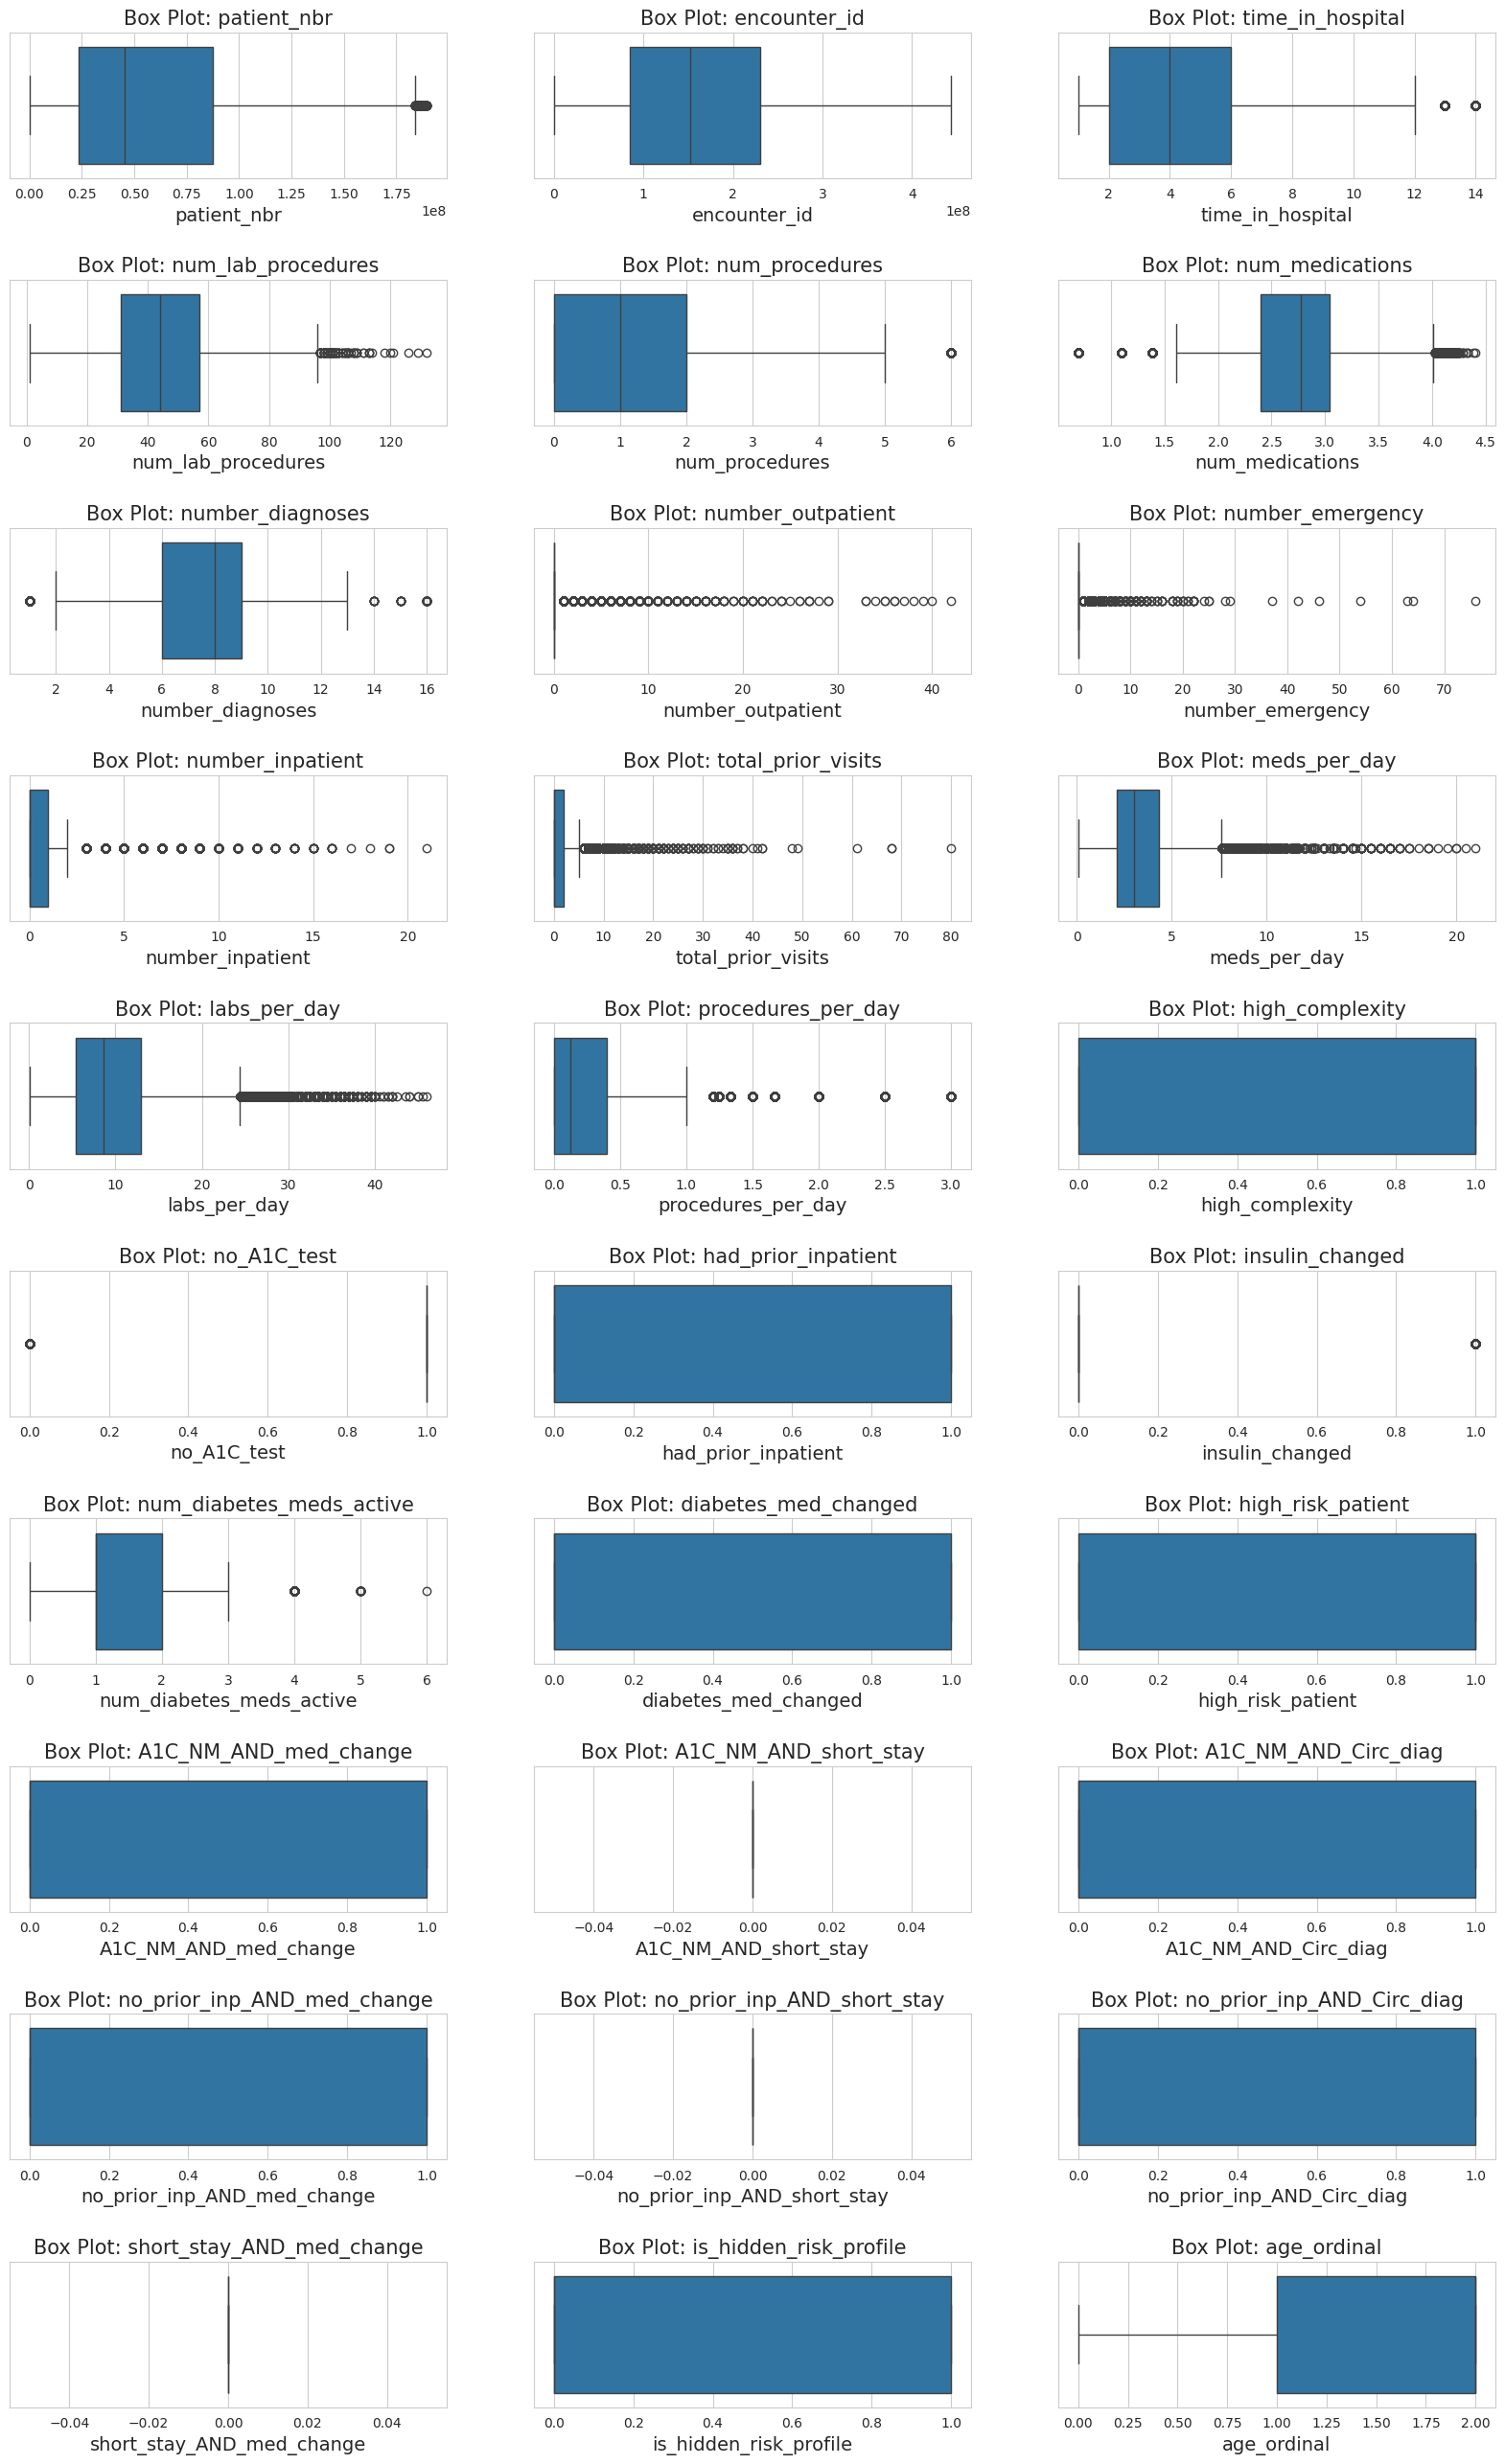

In [8]:
# ===========================
# Outlier Detection: Boxplots for All Numeric Features
# ===========================

print("="*70)
print("📊 Creating Boxplots for Outlier Detection")
print("="*70)

# Create a large figure to accommodate all subplots
plt.figure(figsize=(20, 200))

def outliers_boxplot(df, verbose=True):
    """
    Creates boxplots for all numeric columns in the dataframe to visualize outliers.
    Also prints summary statistics for each feature.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the data to plot
    verbose : bool, default=True
        If True, prints summary statistics for each feature

    Notes:
    ------
    - Each boxplot shows the distribution and potential outliers for one feature
    - Outliers are typically shown as individual points beyond the whiskers
    - The box represents the interquartile range (IQR: 25th to 75th percentile)
    - The line inside the box represents the median
    - Whiskers extend to 1.5 * IQR from the quartiles
    """

    # Select only numeric columns for boxplot analysis
    numeric_cols = df.select_dtypes(include='number').columns

    print(f"Creating boxplots for {len(numeric_cols)} numeric features...")
    print()

    # Iterate through each numeric column
    for i, col in enumerate(numeric_cols):
        # Create subplot for current column
        ax = plt.subplot(60, 3, i+1)

        # Create boxplot
        sb.boxplot(data=df, x=col, ax=ax)

        # Adjust spacing between subplots for better readability
        plt.subplots_adjust(hspace=0.7)

        # Set title and labels
        plt.title(f'Box Plot: {col}', fontsize=15)
        plt.xlabel(f'{col}', fontsize=14)

        # Optional: Print summary statistics
        if verbose and i < 10:  # Print only first 10 to avoid clutter
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outlier_threshold_low = Q1 - 1.5 * IQR
            outlier_threshold_high = Q3 + 1.5 * IQR
            n_outliers = ((df[col] < outlier_threshold_low) | (df[col] > outlier_threshold_high)).sum()

            if n_outliers > 0:
                print(f"  {col}: {n_outliers} potential outliers detected")

# Generate all boxplots
outliers_boxplot(df_new, verbose=True)

print()
print("✅ Boxplots created successfully!")
print("   Review the plots to identify features with significant outliers")
print("   Consider outlier treatment strategies for features with extreme values")
print("="*70)

## 9. Log Transformation for Skewed Features

Apply log transformation to highly skewed numerical features to normalize distributions.

In [9]:
# ===========================
# Log Transformation for Skewed Features
# ===========================

"""
Why Log Transformation?
-----------------------
- Reduces the impact of extreme values (outliers)
- Makes the distribution more normal/symmetric
- Helps machine learning models that assume normality
- Improves interpretability by putting features on similar scales

Why log1p (log(x+1))?
--------------------
- Regular log(x) fails for x=0 (undefined)
- log1p(x) = log(x+1) handles zeros gracefully
- Preserves the ordering of values
"""

# These columns were identified in the Box Plots as having extreme skewness
# We also include the new features we created that are counts or ratios
cols_to_log_transform = [
    'number_inpatient',      # Prior inpatient visits - highly skewed (many zeros)
    'number_outpatient',     # Prior outpatient visits - highly skewed
    'number_emergency',      # Prior emergency visits - highly skewed
    'num_procedures',        # Number of procedures - right-skewed
    'num_medications',       # Number of medications - long tail distribution
    'total_prior_visits',    # New feature: sum of all prior visits
    'meds_per_day',          # New ratio feature: medications per hospital day
    'labs_per_day',          # New ratio feature: lab procedures per hospital day
    'procedures_per_day'     # New ratio feature: procedures per hospital day
]

print("="*70)
print("🔄 Applying Log1p Transform (Handling Skewness)")
print("="*70)
print(f"Transforming {len(cols_to_log_transform)} features...")
print()

# Track transformation results
transformed_count = 0
skipped_count = 0

# Verify that the column exists before attempting transformation
for col in cols_to_log_transform:
    if col in df_new.columns:
        # Store original stats for comparison (optional)
        original_mean = df_new[col].mean()
        original_std = df_new[col].std()

        # Use np.log1p which is shorthand for log(x+1)
        # This is essential to handle zero values (since log(0) is undefined)
        df_new[col] = np.log1p(df_new[col])

        # New stats after transformation
        new_mean = df_new[col].mean()
        new_std = df_new[col].std()

        print(f"✅ {col}")
        print(f"   Original: mean={original_mean:.2f}, std={original_std:.2f}")
        print(f"   After log1p: mean={new_mean:.2f}, std={new_std:.2f}")

        transformed_count += 1
    else:
        print(f"⚠️ Column '{col}' not found, skipping transform.")
        skipped_count += 1

print()
print("="*70)
print("✅ Log transformation complete!")
print(f"   Transformed: {transformed_count} features")
print(f"   Skipped: {skipped_count} features")
print("   These transformations help reduce skewness and improve model performance")
print("="*70)

🔄 Applying Log1p Transform (Handling Skewness)
Transforming 9 features...

✅ number_inpatient
   Original: mean=0.63, std=1.26
   After log1p: mean=0.32, std=0.51
✅ number_outpatient
   Original: mean=0.37, std=1.26
   After log1p: mean=0.17, std=0.43
✅ number_emergency
   Original: mean=0.20, std=0.94
   After log1p: mean=0.10, std=0.32
✅ num_procedures
   Original: mean=1.33, std=1.70
   After log1p: mean=0.62, std=0.65
✅ num_medications
   Original: mean=2.72, std=0.49
   After log1p: mean=1.30, std=0.14
✅ total_prior_visits
   Original: mean=1.20, std=2.29
   After log1p: mean=0.51, std=0.66
✅ meds_per_day
   Original: mean=3.48, std=1.95
   After log1p: mean=1.42, std=0.40
✅ labs_per_day
   Original: mean=9.72, std=6.15
   After log1p: mean=2.18, std=0.67
✅ procedures_per_day
   Original: mean=0.30, std=0.48
   After log1p: mean=0.21, std=0.28

✅ Log transformation complete!
   Transformed: 9 features
   Skipped: 0 features
   These transformations help reduce skewness and improve

## 10. Define Categorical Features

Identify and list all categorical features including engineered ones.

In [10]:
# ===========================
# Categorical Features Definition
# ===========================

"""
Categorical Features Strategy
------------------------------
This section defines all categorical (non-numeric) features in the dataset.
These features will need special encoding (e.g., One-Hot Encoding, Label Encoding)
before being used in machine learning models.

Categories include:
- Demographics (race, gender)
- Admission/discharge information
- Medical specialties and payer codes
- Diagnosis categories (primary, secondary, additional)
- A1C test results
- Medication status (dosage changes, yes/no)
"""

print("="*70)
print("📋 Defining Categorical Features")
print("="*70)

cat_features = [
    # ==================
    # Demographics
    # ==================
    'race',                # Patient's race
    'gender',              # Patient's gender

    # ==================
    # Admission and Discharge
    # ==================
    'admission_grouped',         # Grouped admission type (Emergency, Urgent, Elective, etc.)
    'admission_source_grouped',  # Where patient was admitted from
    'discharge_grouped',         # Where patient was discharged to

    # ==================
    # Medical Information
    # ==================
    'specialty_grouped',   # Medical specialty of the admitting physician (grouped)
    # 'specialty_grouped_binned',  # Commented out - decide if you need this AND specialty_grouped
    'payer_grouped',       # Payment/insurance code (grouped)

    # ==================
    # Diagnoses - Categories! (ICD9 codes grouped into categories)
    # ==================
    'diag_1_category',     # Primary diagnosis category
    'diag_2_category',     # Secondary diagnosis category
    'diag_3_category',     # Additional diagnosis category
    'has_diabetes_code',   # Binary indicator for explicit diabetes code
                           # Note: Check data type - if string '0'/'1', keep here;
                           # if numeric 0/1, consider moving to numeric features

    # ==================
    # A1C Test Results
    # ==================
    'A1Cresult',           # HbA1c test result (None/Norm/>7%/>8%)

    # ==================
    # Medications (dosage status)
    # ==================
    'metformin',           # Metformin dosage status (No/Steady/Up/Down)
    'glimepiride',         # Glimepiride dosage status
    'glipizide',           # Glipizide dosage status
    'glyburide',           # Glyburide dosage status
    'pioglitazone',        # Pioglitazone dosage status
    'rosiglitazone',       # Rosiglitazone dosage status
    'insulin',             # Insulin dosage status
    'diabetesMed',         # Patient on diabetes medication? (Yes/No)
    'change',              # Any diabetes medication changed? (Ch/No)
]

# Validate and filter features
print(f"Checking {len(cat_features)} potential categorical features...")
print()

cat_features_original = cat_features.copy()
cat_features = [col for col in cat_features if col in df_new.columns]

# Summary
found_count = len(cat_features)
missing_count = len(cat_features_original) - found_count

print(f"✅ Total categorical features defined: {len(cat_features_original)}")
print(f"✅ Features found in dataframe: {found_count}")

if missing_count > 0:
    print(f"⚠️  Features missing from dataframe: {missing_count}")
    missing_features = [col for col in cat_features_original if col not in df_new.columns]
    for feat in missing_features:
        print(f"   - {feat}")
else:
    print("✅ All defined categorical features are present!")



📋 Defining Categorical Features
Checking 21 potential categorical features...

✅ Total categorical features defined: 21
✅ Features found in dataframe: 21
✅ All defined categorical features are present!


## 11. Prepare Features and Target

Separate features (X) and target variable (y) for model training.

In [11]:

# ===========================
# Prepare Features (X) and Target (y) for Modeling
# ===========================

"""
Data Preparation for Machine Learning
--------------------------------------
This step separates the dataset into:
- X (features): All columns used to make predictions
- y (target): The variable we're trying to predict (readmission within 30 days)

Columns removed:
- Target variable (readmitted_binary)
- Patient and encounter IDs (not predictive, just identifiers)
"""

print("="*70)
print("🎯 Preparing Data for Machine Learning")
print("="*70)

# Define the target variable (what we're trying to predict)
# Binary classification: 0 = Not readmitted within 30 days, 1 = Readmitted within 30 days
target_variable = 'readmitted_binary'

# Verify target variable exists
if target_variable not in df_new.columns:
    raise ValueError(f"⚠️ Target variable '{target_variable}' not found in dataframe!")

print(f"Target variable: '{target_variable}'")

# Define columns to drop (target + non-predictive identifiers)
columns_to_drop = [
    target_variable,    # Target variable - will be stored separately in y
    'patient_nbr',      # Patient identifier - not predictive, just for tracking
    'encounter_id'      # Encounter identifier - not predictive, just for tracking
]

# Check which columns will actually be dropped
columns_found = [col for col in columns_to_drop if col in df_new.columns]
columns_not_found = [col for col in columns_to_drop if col not in df_new.columns]

print(f"\nColumns to drop: {len(columns_to_drop)}")
for col in columns_found:
    print(f"   ✅ {col}")
for col in columns_not_found:
    print(f"   ⚠️  {col} (not found in dataframe)")

# Separate target variable (y) and features (X)
y = df_new[target_variable]
X = df_new.drop(columns=columns_to_drop, errors='ignore')

# Display summary
print("\n" + "-"*70)
print("📊 Data Summary:")
print("-"*70)
print(f"Total samples: {len(y):,}")
print(f"Total features: {X.shape[1]}")
print(f"Feature names: {list(X.columns[:10])}..." if len(X.columns) > 10 else f"Feature names: {list(X.columns)}")

print("\n" + "-"*70)
print("🎯 Target Variable Distribution:")
print("-"*70)
target_counts = y.value_counts().sort_index()
for class_value in target_counts.index:
    count = target_counts[class_value]
    percentage = (count / len(y)) * 100
    label = "Not readmitted" if class_value == 0 else "Readmitted"
    print(f"   Class {class_value} ({label}): {count:,} ({percentage:.2f}%)")

# Check for class imbalance
imbalance_ratio = target_counts.max() / target_counts.min()
if imbalance_ratio > 2:
    print(f"\n⚠️  Class imbalance detected (ratio: {imbalance_ratio:.2f}:1)")
else:
    print(f"\n✅ Classes are relatively balanced (ratio: {imbalance_ratio:.2f}:1)")

print("="*70)

🎯 Preparing Data for Machine Learning
Target variable: 'readmitted_binary'

Columns to drop: 3
   ✅ readmitted_binary
   ✅ patient_nbr
   ✅ encounter_id

----------------------------------------------------------------------
📊 Data Summary:
----------------------------------------------------------------------
Total samples: 100,114
Total features: 49
Feature names: ['race', 'gender', 'admission_grouped', 'specialty_grouped', 'admission_source_grouped', 'payer_grouped', 'discharge_grouped', 'time_in_hospital', 'num_lab_procedures', 'num_procedures']...

----------------------------------------------------------------------
🎯 Target Variable Distribution:
----------------------------------------------------------------------
   Class False (Not readmitted): 88,757 (88.66%)
   Class True (Readmitted): 11,357 (11.34%)

⚠️  Class imbalance detected (ratio: 7.82:1)


## 12. Train-Validation-Test Split

Split dataset into training (70%), validation (15%), and test (15%) sets.

In [12]:
# ===========================
# Train-Validation-Test Split (70/15/15)
# ===========================

print("="*70)
print("✂️  Splitting Data: 70% Train / 15% Validation / 15% Test")
print("="*70)

# Step 1: Main split (70% train / 30% temporary)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,      # 30% for validation + test
    random_state=42,
    stratify=y           # Maintain class distribution
)

# Step 2: Split temporary set into validation and test (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,      # 50% of 30% = 15% of original data
    random_state=42,
    stratify=y_temp      # Maintain class distribution
)

# Summary
print("\n📊 Split Summary:")
print("-" * 70)
total = len(X)
print(f"Total samples: {total:,}")
print(f"Training:   {len(X_train):>7,} ({len(X_train)/total*100:>5.1f}%)  -  {X_train.shape[1]} features")
print(f"Validation: {len(X_val):>7,} ({len(X_val)/total*100:>5.1f}%)  -  {X_val.shape[1]} features")
print(f"Test:       {len(X_test):>7,} ({len(X_test)/total*100:>5.1f}%)  -  {X_test.shape[1]} features")

# Verify stratification
print("\n🎯 Class Distribution:")
print("-" * 70)
for name, y_set in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    dist = y_set.value_counts(normalize=True).sort_index() * 100
    print(f"{name:>10}: Class 0: {dist[0]:.2f}%  |  Class 1: {dist[1]:.2f}%")

print("="*70)
print("✅ Data split completed successfully!")
print("="*70)

✂️  Splitting Data: 70% Train / 15% Validation / 15% Test

📊 Split Summary:
----------------------------------------------------------------------
Total samples: 100,114
Training:    70,079 ( 70.0%)  -  49 features
Validation:  15,017 ( 15.0%)  -  49 features
Test:        15,018 ( 15.0%)  -  49 features

🎯 Class Distribution:
----------------------------------------------------------------------
     Train: Class 0: 88.66%  |  Class 1: 11.34%
       Val: Class 0: 88.66%  |  Class 1: 11.34%
      Test: Class 0: 88.65%  |  Class 1: 11.35%
✅ Data split completed successfully!


## 13. One-Hot Encoding

Convert categorical variables to numerical format using one-hot encoding with alignment across splits.

In [13]:
# ===========================
# One-Hot Encoding with Alignment
# ===========================

print("\n" + "="*70)
print("🔧 One-Hot Encoding: Train/Validation/Test Splits")
print("="*70)

# Note: Assumes 'cat_features' list is already defined

# Step 1: Encode all three sets
print(f"Encoding {len(cat_features)} categorical features...")
X_train_ohe = pd.get_dummies(X_train.copy(), columns=cat_features, drop_first=True, dtype=int)
X_val_ohe = pd.get_dummies(X_val.copy(), columns=cat_features, drop_first=True, dtype=int)
X_test_ohe = pd.get_dummies(X_test.copy(), columns=cat_features, drop_first=True, dtype=int)

print(f"Before alignment: Train={X_train_ohe.shape}, Val={X_val_ohe.shape}, Test={X_test_ohe.shape}")

# Step 2: *** CRITICAL ALIGNMENT STEP ***
# Align val/test to have the EXACT same columns as training
# - Missing columns → filled with 0 (category never seen in training)
# - Extra columns → dropped (model not trained on them)
print("\n🔄 Aligning validation and test sets to training structure...")
X_val_ohe = X_val_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)
X_test_ohe = X_test_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

print(f"After alignment:  Train={X_train_ohe.shape}, Val={X_val_ohe.shape}, Test={X_test_ohe.shape}")

# Step 3: Verify
assert X_train_ohe.shape[1] == X_val_ohe.shape[1] == X_test_ohe.shape[1], "Column mismatch!"
print("\n✅ One-hot encoding complete! All sets aligned and ready for modeling.")
print("="*70)


🔧 One-Hot Encoding: Train/Validation/Test Splits
Encoding 21 categorical features...
Before alignment: Train=(70079, 117), Val=(15017, 117), Test=(15018, 117)

🔄 Aligning validation and test sets to training structure...
After alignment:  Train=(70079, 117), Val=(15017, 117), Test=(15018, 117)

✅ One-hot encoding complete! All sets aligned and ready for modeling.


## 14. Outlier Handling (Feature Capping)

Cap outliers using quantile-based thresholds to reduce extreme values' impact.

In [14]:
# ===========================
# Feature Capping by Quantiles (Outlier Treatment)
# ===========================

def cap_features_by_quantile_3(X_train, X_val, X_test, cols_to_cap, lower_quantile=0.01, upper_quantile=0.99):
    """
    Caps (clips) specific columns in three datasets to reduce the impact of outliers.

    The function learns the capping boundaries (quantiles) ONLY from the training set (X_train)
    and applies them consistently to X_train, X_val, and X_test.

    Parameters:
    -----------
    X_train : pd.DataFrame
        Training set features
    X_val : pd.DataFrame
        Validation set features
    X_test : pd.DataFrame
        Test set features
    cols_to_cap : list
        List of column names to cap
    lower_quantile : float, default=0.01
        Lower quantile threshold (e.g., 0.01 = 1st percentile)
    upper_quantile : float, default=0.99
        Upper quantile threshold (e.g., 0.99 = 99th percentile)

    Returns:
    --------
    tuple of pd.DataFrame
        Capped versions of X_train, X_val, X_test

    Important:
    ----------
    - Boundaries are learned ONLY from training data to prevent data leakage
    - Values below lower_quantile are set to lower_quantile value
    - Values above upper_quantile are set to upper_quantile value
    - This reduces the impact of extreme outliers on model training
    """

    print(f"\n{'='*70}")
    print(f"🔒 Capping features at {lower_quantile*100}% and {upper_quantile*100}% quantiles")
    print(f"{'='*70}")

    # Create copies to avoid SettingWithCopyWarning
    X_train_capped = X_train.copy()
    X_val_capped = X_val.copy()
    X_test_capped = X_test.copy()

    for col in cols_to_cap:
        if col in X_train_capped.columns:
            # Step 1: Learn the boundaries ONLY from the training set
            lower_limit = X_train_capped[col].quantile(lower_quantile)
            upper_limit = X_train_capped[col].quantile(upper_quantile)

            print(f"  ✅ {col}: Limits learned [Lower: {lower_limit:.2f}, Upper: {upper_limit:.2f}]")

            # Step 2: Apply capping (using .clip()) to all three sets
            X_train_capped[col] = X_train_capped[col].clip(lower=lower_limit, upper=upper_limit)
            X_val_capped[col] = X_val_capped[col].clip(lower=lower_limit, upper=upper_limit)
            X_test_capped[col] = X_test_capped[col].clip(lower=lower_limit, upper=upper_limit)
        else:
            print(f"  ⚠️  Warning: Column '{col}' not found in DataFrame, skipping.")

    print(f"{'='*70}")
    return X_train_capped, X_val_capped, X_test_capped


# ================================================================
# Apply Feature Capping to One-Hot Encoded Sets
# ================================================================

print("\n" + "="*70)
print("⭐ Applying Feature Capping to Reduce Outlier Impact")
print("="*70)

# Step 1: Define columns that require capping
# These are columns that did NOT undergo log transformation
columns_to_cap = [
    'time_in_hospital',      # Hospital stay duration (days)
    'num_lab_procedures',    # Number of lab tests performed
    'number_diagnoses'       # Total number of diagnoses
]

print(f"Columns to cap: {columns_to_cap}")
print(f"Capping strategy: Remove extreme outliers while preserving data structure")

# Step 2: Apply the capping function to the one-hot encoded sets
X_train_capped, X_val_capped, X_test_capped = cap_features_by_quantile_3(
    X_train_ohe,
    X_val_ohe,
    X_test_ohe,
    cols_to_cap=columns_to_cap,
    lower_quantile=0.01,  # Cap values below 1st percentile
    upper_quantile=0.99   # Cap values above 99th percentile
)

# Step 3: Verify results
print("\n" + "-"*70)
print("📊 Summary:")
print("-"*70)
print(f"✅ Capping complete for one-hot encoded sets")
print(f"   X_train_capped shape: {X_train_capped.shape}")
print(f"   X_val_capped shape:   {X_val_capped.shape}")
print(f"   X_test_capped shape:  {X_test_capped.shape}")
print(f"   Features capped: {len(columns_to_cap)}")
print("="*70)


⭐ Applying Feature Capping to Reduce Outlier Impact
Columns to cap: ['time_in_hospital', 'num_lab_procedures', 'number_diagnoses']
Capping strategy: Remove extreme outliers while preserving data structure

🔒 Capping features at 1.0% and 99.0% quantiles
  ✅ time_in_hospital: Limits learned [Lower: 1.00, Upper: 14.00]
  ✅ num_lab_procedures: Limits learned [Lower: 1.00, Upper: 84.00]
  ✅ number_diagnoses: Limits learned [Lower: 2.00, Upper: 9.00]

----------------------------------------------------------------------
📊 Summary:
----------------------------------------------------------------------
✅ Capping complete for one-hot encoded sets
   X_train_capped shape: (70079, 117)
   X_val_capped shape:   (15017, 117)
   X_test_capped shape:  (15018, 117)
   Features capped: 3


## 15. Feature Scaling (Standardization)

Standardize numerical features to have mean=0 and std=1 for improved model convergence.

In [15]:
# ===========================
# Feature Scaling (Standardization)
# ===========================

"""
Why Scale Features?
-------------------
- Many ML algorithms (e.g., Logistic Regression, SVM, Neural Networks) are sensitive to feature scales
- Features with larger ranges can dominate the learning process
- StandardScaler transforms features to have mean=0 and standard deviation=1
- This puts all features on the same scale, improving model performance

Important: Fit on training data only to prevent data leakage!
"""

print("\n" + "="*70)
print("📏 Scaling Features Using StandardScaler")
print("="*70)

# Step 1: Initialize the Scaler
scaler = StandardScaler()

# Step 2: Learn the mean and standard deviation ONLY from the training set (X_train_capped)
#         and immediately apply the transformation (this is what fit_transform does)
print("Learning scaling parameters from training set...")
X_train_scaled = scaler.fit_transform(X_train_capped)
print(f"✅ Training set scaled: {X_train_scaled.shape}")

# Step 3: Apply the SAME scaling (using training statistics) to the validation set
print("Applying training scaling parameters to validation set...")
X_val_scaled = scaler.transform(X_val_capped)
print(f"✅ Validation set scaled: {X_val_scaled.shape}")

# Step 4: Apply the SAME scaling (using training statistics) to the test set
print("Applying training scaling parameters to test set...")
X_test_scaled = scaler.transform(X_test_capped)
print(f"✅ Test set scaled: {X_test_scaled.shape}")

# Verification
print("\n" + "-"*70)
print("📊 Scaling Summary:")
print("-"*70)
print(f"Training set:   {X_train_scaled.shape}")
print(f"Validation set: {X_val_scaled.shape}")
print(f"Test set:       {X_test_scaled.shape}")
print("\n✅ Scaling complete! Data is ready for ML models (e.g., Logistic Regression, SVM)")

# Note: The output (e.g., X_train_scaled) is a NumPy array, not a DataFrame.
# This is the exact format that scikit-learn expects for model training.
print("\nℹ️  Note: Scaled data is in NumPy array format (required by scikit-learn)")
print("="*70)


📏 Scaling Features Using StandardScaler
Learning scaling parameters from training set...
✅ Training set scaled: (70079, 117)
Applying training scaling parameters to validation set...
✅ Validation set scaled: (15017, 117)
Applying training scaling parameters to test set...
✅ Test set scaled: (15018, 117)

----------------------------------------------------------------------
📊 Scaling Summary:
----------------------------------------------------------------------
Training set:   (70079, 117)
Validation set: (15017, 117)
Test set:       (15018, 117)

✅ Scaling complete! Data is ready for ML models (e.g., Logistic Regression, SVM)

ℹ️  Note: Scaled data is in NumPy array format (required by scikit-learn)


## 16. Class Balancing Strategy Comparison

Compare different class balancing techniques: SMOTE, Random Oversampling, and Class Weights.

In [16]:
# ===========================
# Class Balancing Strategy Comparison
# ===========================

"""
Testing Different Balancing Techniques
---------------------------------------
This script tests multiple strategies to handle class imbalance in the dataset:
1. SMOTE (Synthetic Minority Over-sampling Technique)
2. Random Over-sampling
3. Random Under-sampling
4. No Balancing (baseline)
"""



print("=" * 80)
print("STEP 5.5: Testing Different Class Balancing Techniques")
print("=" * 80)

# ================================================================
# 0. Check Target Variable Distribution
# ================================================================
print("\n0️⃣  Original Training Set - Target Variable Distribution:")
print(y_train.value_counts())
print(f"   Class imbalance ratio: {y_train.value_counts()[0] / y_train.value_counts()[1]:.2f}:1")

# ================================================================
# 1. Define Balancing Methods to Test
# ================================================================
balancing_methods = {
    'SMOTE': SMOTE(random_state=42),                          # Synthetic samples of minority class
    'RandomOverSampler': RandomOverSampler(random_state=42),  # Duplicate minority class samples
    'RandomUnderSampler': RandomUnderSampler(random_state=42),# Remove majority class samples
    'No Balancing': None                                       # Baseline (original distribution)
}

print(f"\n1️⃣  Testing {len(balancing_methods)} balancing strategies:")
for method_name in balancing_methods.keys():
    print(f"   • {method_name}")

# ================================================================
# 2. Initialize Results Storage
# ================================================================
results = {}

# ================================================================
# 3. Test Each Balancing Method
# ================================================================
# Pipeline: (OHE + Capped Data) → Balance → Scale → Train → Evaluate

for name, method in balancing_methods.items():
    print(f"\n{'='*80}")
    print(f"🧪 Testing: {name}")
    print(f"{'='*80}")

    # --- Step 3a: Apply Balancing (if any) ---
    # Use data that has undergone OHE and capping (but NOT scaling yet)
    if method is None:
        # No balancing - use original training data
        X_train_resampled = X_train_capped.copy()
        y_train_resampled = y_train.copy()
    else:
        # Apply balancing to the encoded and capped data (not yet scaled)
        X_train_resampled, y_train_resampled = method.fit_resample(X_train_capped, y_train)

    print(f"Training set size after {name}: {X_train_resampled.shape}")
    print(f"Class distribution after balancing:")
    print(pd.Series(y_train_resampled).value_counts())

    # --- Step 3b: Scale Data AFTER Balancing ---
    # Initialize a NEW scaler inside the loop (important!)
    scaler = StandardScaler()

    # Learn scaling parameters ONLY from the balanced training set
    X_train_scaled = scaler.fit_transform(X_train_resampled)

    # Apply the same scaling to the validation set
    # NOTE: Validation set is NEVER balanced (we evaluate on real-world distribution)
    X_val_scaled = scaler.transform(X_val_capped)

    # --- Step 3c: Train Model ---
    model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')
    model.fit(X_train_scaled, y_train_resampled)

    # --- Step 3d: Evaluate on Validation Set ---
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]

    # Calculate metrics
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred)

    # Calculate PR-AUC (Precision-Recall Area Under Curve)
    precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_proba)
    pr_auc = auc(recall_curve, precision_curve)

    # Store results
    results[name] = {
        'Recall': recall,
        'Precision': precision,
        'F1-Score': f1,
        'PR-AUC': pr_auc
    }

    print(f"\n📊 Validation Results:")
    print(f"   Recall:    {recall:.4f} ← % of actual readmissions caught")
    print(f"   Precision: {precision:.4f} ← % of predicted readmissions that are correct")
    print(f"   F1-Score:  {f1:.4f} ← Harmonic mean of Precision & Recall")
    print(f"   PR-AUC:    {pr_auc:.4f} ← Overall performance metric")

# ================================================================
# 4. Compare All Methods and Rank by RECALL
# ================================================================
print("\n" + "=" * 80)
print("📊 COMPARISON - ALL METHODS (Sorted by Recall)")
print("=" * 80)

results_df = pd.DataFrame(results).T.sort_values(by='Recall', ascending=False)
print(results_df.to_string())

# ================================================================
# 5. Select Best Method Based on RECALL
# ================================================================
best_method_name = results_df.index[0]

print(f"\n{'='*80}")
print(f"🏆 BEST METHOD (by Recall): {best_method_name}")
print(f"{'='*80}")
print(f"   Recall:    {results_df.loc[best_method_name, 'Recall']:.4f}")
print(f"   Precision: {results_df.loc[best_method_name, 'Precision']:.4f}")
print(f"   F1-Score:  {results_df.loc[best_method_name, 'F1-Score']:.4f}")
print(f"   PR-AUC:    {results_df.loc[best_method_name, 'PR-AUC']:.4f}")

# Clinical interpretation
recall_pct = results_df.loc[best_method_name, 'Recall'] * 100
precision_pct = results_df.loc[best_method_name, 'Precision'] * 100

print(f"\n💡 Clinical Interpretation:")
print(f"   • Out of 100 actual readmissions, we catch: {recall_pct:.1f}")
print(f"   • Out of 100 predicted readmissions, {precision_pct:.1f} are correct")
print(f"\n   Why Recall matters in healthcare:")
print(f"   Missing a high-risk patient (false negative) is more costly than")
print(f"   flagging a low-risk patient for review (false positive)")

# ================================================================
# 6. Create FINAL Processed Sets Using Best Method
# ================================================================
print(f"\n{'='*80}")
print(f"🎯 CREATING FINAL PROCESSED SETS (Using {best_method_name})")
print(f"{'='*80}")

# Step 6a: Apply best balancing method to training set
if best_method_name == 'No Balancing':
    X_train_final_balanced = X_train_capped.copy()
    y_train_final_balanced = y_train.copy()
    print("✓ Using original (unbalanced) training data")
else:
    best_method = balancing_methods[best_method_name]
    X_train_final_balanced, y_train_final_balanced = best_method.fit_resample(
        X_train_capped,
        y_train
    )
    print(f"✓ Applied {best_method_name} to training data")

print(f"   Training samples after balancing: {X_train_final_balanced.shape[0]:,}")
print(f"   Class distribution:")
print(pd.Series(y_train_final_balanced).value_counts())

# Step 6b: Apply final scaling
print("\n✓ Applying final scaling...")
final_scaler = StandardScaler()

# Learn scaling parameters ONLY from the final balanced training set
X_train_final_scaled = final_scaler.fit_transform(X_train_final_balanced)

# Apply the same scaling to validation and test sets (which remain unbalanced)
X_val_final_scaled = final_scaler.transform(X_val_capped)
X_test_final_scaled = final_scaler.transform(X_test_capped)

# ================================================================
# 7. Final Summary
# ================================================================
print("\n" + "=" * 80)
print("✅ FINAL PROCESSED SETS - READY FOR MODELING")
print("=" * 80)
print(f"Training set:   {X_train_final_scaled.shape}")
print(f"   Samples: {X_train_final_scaled.shape[0]:,}")
print(f"   Features: {X_train_final_scaled.shape[1]:,}")
print(f"   Target shape: {y_train_final_balanced.shape}")
print(f"\nValidation set: {X_val_final_scaled.shape}")
print(f"   Samples: {X_val_final_scaled.shape[0]:,}")
print(f"\nTest set:       {X_test_final_scaled.shape}")
print(f"   Samples: {X_test_final_scaled.shape[0]:,}")



STEP 5.5: Testing Different Class Balancing Techniques

0️⃣  Original Training Set - Target Variable Distribution:
readmitted_binary
False    62129
True      7950
Name: count, dtype: int64
   Class imbalance ratio: 7.81:1

1️⃣  Testing 4 balancing strategies:
   • SMOTE
   • RandomOverSampler
   • RandomUnderSampler
   • No Balancing

🧪 Testing: SMOTE
Training set size after SMOTE: (124258, 117)
Class distribution after balancing:
readmitted_binary
False    62129
True     62129
Name: count, dtype: int64

📊 Validation Results:
   Recall:    0.0887 ← % of actual readmissions caught
   Precision: 0.1811 ← % of predicted readmissions that are correct
   F1-Score:  0.1190 ← Harmonic mean of Precision & Recall
   PR-AUC:    0.1390 ← Overall performance metric

🧪 Testing: RandomOverSampler
Training set size after RandomOverSampler: (124258, 117)
Class distribution after balancing:
readmitted_binary
False    62129
True     62129
Name: count, dtype: int64

📊 Validation Results:
   Recall:    0.

## 17. Feature Selection Using Random Forest

Select most important features using Random Forest feature importance scores.

In [17]:
# ===========================
# Feature Selection Using Random Forest Feature Importance
# ===========================

"""
Feature Selection Strategy
--------------------------
Using Random Forest to identify the most important features:
1. Train Random Forest on the fully processed data
2. Extract feature importance scores
3. Select top N features (default: 50)
4. Create final datasets with only selected features

Benefits:
- Reduces model complexity and training time
- Reduces overfitting risk
- Improves model interpretability
- May improve performance by removing noise
"""

print("=" * 80)
print("🔍 FEATURE SELECTION: Random Forest Feature Importance")
print("=" * 80)

# ================================================================
# Step 1: Train Random Forest for Feature Selection
# ================================================================
print("\n1️⃣  Training Random Forest for feature selection...")
print("   (Using the fully processed, balanced, and scaled training data)")

rf = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    random_state=42,       # For reproducibility
    n_jobs=-1,            # Use all available CPU cores
    max_depth=10          # Limit tree depth to prevent overfitting
)

# *** Fix 1: Train the model on the final scaled and balanced data ***
# (X_train_balanced_final was before scaling, this is better)
rf.fit(X_train_final_scaled, y_train_final_balanced)
print(f"   ✓ Random Forest trained on {X_train_final_scaled.shape[0]:,} samples")
print(f"   ✓ Number of features: {X_train_final_scaled.shape[1]}")

# ================================================================
# Step 2: Extract Feature Importances
# ================================================================
print("\n2️⃣  Extracting feature importances...")

importances = rf.feature_importances_

# *** Fix 2: Use the correct column list ***
# X_train.columns is WRONG (contains text, ~49 columns)
# X_train_capped.columns is CORRECT (contains OHE features, 113 columns)
feature_importance_df = pd.DataFrame({
    'Feature': X_train_capped.columns,  # <--- This is the critical fix
    'Importance': importances
})

# Sort by importance (descending)
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(f"   ✓ Feature importances calculated for {len(feature_importance_df)} features")

# ================================================================
# Step 3: Select Top N Features
# ================================================================
TOP_N_FEATURES = 50

print(f"\n3️⃣  Top {TOP_N_FEATURES} Most Important Features")
print("=" * 80)
print(feature_importance_df.head(TOP_N_FEATURES).to_string(index=False))
print("=" * 80)

selected_features_list = feature_importance_df.head(TOP_N_FEATURES)['Feature'].tolist()

cumulative_importance = feature_importance_df.head(TOP_N_FEATURES)['Importance'].sum()
print(f"\n📊 Cumulative importance of top {TOP_N_FEATURES} features: {cumulative_importance:.4f}")
print(f"   ({cumulative_importance*100:.2f}% of total importance captured)")

# ================================================================
# Step 4: Create Final Datasets with Selected Features Only
# ================================================================
print(f"\n{'='*80}")
print("4️⃣  Creating Final Datasets (with selected features only)")
print(f"{'='*80}")

# *** Fix 3: Convert the correct NumPy arrays back to DataFrames ***
# We use the final variable names from the balancing step

# Convert X_train_final_scaled back to DataFrame
X_train_scaled_df = pd.DataFrame(
    X_train_final_scaled,
    columns=X_train_capped.columns  # Use the same correct columns
)

# Convert X_val_final_scaled back to DataFrame
X_val_scaled_df = pd.DataFrame(
    X_val_final_scaled,    # <--- Fix 3a: Use correct variable name
    columns=X_train_capped.columns
)

# Convert X_test_final_scaled back to DataFrame
X_test_scaled_df = pd.DataFrame(
    X_test_final_scaled,   # <--- Fix 3b: Use correct variable name
    columns=X_train_capped.columns
)

print("   ✓ Converted NumPy arrays back to DataFrames")

# *** Fix 4: Select the variables from the new DataFrames ***
X_train_selected = X_train_scaled_df[selected_features_list]
X_val_selected = X_val_scaled_df[selected_features_list]      # <--- Fix 4a: Updated variable name
X_test_selected = X_test_scaled_df[selected_features_list]

# Assign the correct target variables (y)
y_train_selected = y_train_final_balanced  # Balanced target
y_val_selected = y_val                     # Original validation target
y_test_selected = y_test                   # Original test target

print("   ✓ Selected top features from all datasets")

# ================================================================
# Step 5: Summary
# ================================================================
print(f"\n{'='*80}")
print("📊 FINAL DATASETS SUMMARY (with selected features)")
print(f"{'='*80}")

print(f"\nTraining Set:")
print(f"   X_train_selected: {X_train_selected.shape}")
print(f"   - Samples: {X_train_selected.shape[0]:,}")
print(f"   - Features: {X_train_selected.shape[1]}")
print(f"   y_train_selected: {y_train_selected.shape}")

print(f"\nValidation Set:")
print(f"   X_val_selected: {X_val_selected.shape}")      # <--- Fix 4b: Updated variable name
print(f"   - Samples: {X_val_selected.shape[0]:,}")
print(f"   - Features: {X_val_selected.shape[1]}")
print(f"   y_val_selected: {y_val_selected.shape}")

print(f"\nTest Set:")
print(f"   X_test_selected: {X_test_selected.shape}")
print(f"   - Samples: {X_test_selected.shape[0]:,}")
print(f"   - Features: {X_test_selected.shape[1]}")
print(f"   y_test_selected: {y_test_selected.shape}")

# Feature reduction summary
original_features = X_train_final_scaled.shape[1]
selected_features = X_train_selected.shape[1]
reduction_pct = (1 - selected_features / original_features) * 100

print(f"\n📉 Feature Reduction:")
print(f"   Original features: {original_features}")
print(f"   Selected features: {selected_features}")
print(f"   Reduction: {reduction_pct:.1f}%")

print("\n" + "=" * 80)
print("✅ Feature Selection Complete! Ready for Final Modeling")
print("=" * 80)
print("\nNext steps:")
print("   1. Train models using X_train_selected & y_train_selected")
print("   2. Validate using X_val_selected & y_val_selected")
print("   3. Final test using X_test_selected & y_test_selected (once only!)")

🔍 FEATURE SELECTION: Random Forest Feature Importance

1️⃣  Training Random Forest for feature selection...
   (Using the fully processed, balanced, and scaled training data)
   ✓ Random Forest trained on 15,900 samples
   ✓ Number of features: 117

2️⃣  Extracting feature importances...
   ✓ Feature importances calculated for 117 features

3️⃣  Top 50 Most Important Features
                               Feature  Importance
                      number_inpatient    0.091147
                    total_prior_visits    0.057483
discharge_grouped_Transfer_to_Facility    0.053850
                   had_prior_inpatient    0.048428
                          labs_per_day    0.045917
                          meds_per_day    0.041797
                    num_lab_procedures    0.039725
                       num_medications    0.038734
                      time_in_hospital    0.031899
                    procedures_per_day    0.030733
                      number_diagnoses    0.028097
         

# 18. Train Multiple Machine Learning Models

Train and evaluate 5 different ML algorithms: Logistic Regression, Decision Tree, Random Forest, XGBoost, and CatBoost.

In [18]:
# ===========================
# Training and Evaluating Multiple Models
# ===========================

"""
Model Training Pipeline
-----------------------
This script trains and evaluates multiple machine learning models:
- Tree-based models on processed data (OHE + scaled + balanced)
- CatBoost on clean data (handles categorical features natively)

Pipeline for most models:
1. Use data that went through: OHE → Capping → Balancing → Scaling → Feature Selection
2. Train on processed training set
3. Evaluate on processed validation set

Special handling for CatBoost:
- Uses original clean data with text categories
- CatBoost handles categorical encoding internally
- Uses auto_class_weights instead of pre-balanced data
"""

print("=" * 80)
print("🚀 TRAINING AND EVALUATING MODELS")
print("=" * 80)

# ================================================================
# Step 1: Define Data Variables
# ================================================================
# *** Fix 1: Use correct variable names (with capital X) ***
# This is data that went through OHE, Capping, Balancing, Scaling, and Feature Selection
X_train_processed = X_train_selected
y_train_processed = y_train_selected
X_val_processed = X_val_selected      # <--- This was the BUG (x_val_selected with lowercase x)
y_val_processed = y_val_selected

print(f"\n📊 Dataset Information (Processed for most models):")
print(f"   Number of features: {X_train_processed.shape[1]}")
print(f"   Training samples:   {X_train_processed.shape[0]:,}")
print(f"   Validation samples: {X_val_processed.shape[0]:,}")

# ================================================================
# Step 2: Define Models to Test
# ================================================================
print("\n" + "=" * 80)
print("🤖 Models to Evaluate:")
print("=" * 80)

models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=10
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=15
    ),
    "AdaBoost": AdaBoostClassifier(
        random_state=42,
        n_estimators=100
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=5
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
        eval_metric='logloss'
    ),
    "LightGBM": LGBMClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
        verbose=-1
    )
    # *** Fix 2: CatBoost removed from here. We'll handle it separately. ***
}

for name in models.keys():
    print(f"   • {name}")
print("   • CatBoost (Trained separately on clean data)")

# ================================================================
# Step 3: Initialize Results Storage
# ================================================================
results = {}

# ================================================================
# Step 4: Train and Evaluate Each Model (except CatBoost)
# ================================================================
print("\n" + "=" * 80)
print("🏋️ TRAINING MODELS (OHE/Scaled/Balanced Data)")
print("=" * 80)

for name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Training: {name}")
    print(f"{'='*80}")

    start_time = time.time()

    # *** Fix 3: Train on processed data ***
    model.fit(X_train_processed, y_train_processed)

    # *** Fix 4: Predict on processed validation data ***
    y_pred = model.predict(X_val_processed)
    y_proba = model.predict_proba(X_val_processed)[:, 1]

    end_time = time.time()
    train_time = end_time - start_time

    # Calculate metrics
    # *** Fix 5: Compare against y_val_processed ***
    recall = recall_score(y_val_processed, y_pred)
    precision = precision_score(y_val_processed, y_pred, zero_division=0)
    f1 = f1_score(y_val_processed, y_pred)
    precision_curve, recall_curve, _ = precision_recall_curve(y_val_processed, y_proba)
    pr_auc = auc(recall_curve, precision_curve)

    # Store results
    results[name] = {
        "Recall": recall,
        "Precision": precision,
        "F1-Score": f1,
        "PR-AUC": pr_auc,
        "Train Time (s)": train_time
    }

    # Print summary
    print(f"\n⏱️  Training Time: {train_time:.2f} seconds")
    print(f"\n📊 Metrics on Validation Set (Processed):")
    print(f"   Recall:    {recall:.4f} (% of readmissions caught)")
    print(f"   Precision: {precision:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   PR-AUC:    {pr_auc:.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(
        y_val_processed,
        y_pred,
        target_names=['Not Readmitted (0)', 'Readmitted (1)'],
        zero_division=0
    ))

# ================================================================
# Step 5: Train CatBoost Separately (The "Correct" Way)
# ================================================================
print("\n" + "=" * 80)
print("🐱 TRAINING CATBOOST (Clean Data)")
print("=" * 80)
print("   (Using original X_train/X_val with text categories)")
print("   CatBoost handles categorical features natively - no OHE needed!")


try:
    start_time = time.time()

    # Initialize the model (using auto_class_weights instead of pre-balanced data)
    model_cb = CatBoostClassifier(
        random_state=42,
        iterations=500,              # Can use more iterations with early stopping
        depth=6,
        learning_rate=0.05,
        auto_class_weights='Balanced',  # Handles class imbalance internally
        eval_metric='AUC',
        verbose=100                  # Print progress every 100 iterations
    )

    print("\n   Model configuration:")
    print(f"      • Iterations: 500 (with early stopping)")
    print(f"      • Depth: 6")
    print(f"      • Learning rate: 0.05")
    print(f"      • Auto class weights: Balanced")
    print(f"      • Categorical features: {len(cat_features)}")

    # Train on "clean" data
    model_cb.fit(
        X_train, y_train,            # <-- Original sets (with text categories)
        cat_features=cat_features,   # <-- List of categorical feature names
        eval_set=(X_val, y_val),     # <-- Clean validation set
        early_stopping_rounds=50     # Stop if no improvement for 50 rounds
    )

    # Predict on "clean" validation set
    y_pred_cb = model_cb.predict(X_val)
    y_proba_cb = model_cb.predict_proba(X_val)[:, 1]

    end_time = time.time()
    train_time_cb = end_time - start_time

    # Calculate metrics
    recall_cb = recall_score(y_val, y_pred_cb)
    precision_cb = precision_score(y_val, y_pred_cb, zero_division=0)
    f1_cb = f1_score(y_val, y_pred_cb)
    precision_curve_cb, recall_curve_cb, _ = precision_recall_curve(y_val, y_proba_cb)
    pr_auc_cb = auc(recall_curve_cb, precision_curve_cb)

    # Add results to comparison table
    results["CatBoost (Clean)"] = {
        "Recall": recall_cb,
        "Precision": precision_cb,
        "F1-Score": f1_cb,
        "PR-AUC": pr_auc_cb,
        "Train Time (s)": train_time_cb
    }

    print(f"\n⏱️  Training Time: {train_time_cb:.2f} seconds")
    print(f"\n📊 Metrics on Validation Set (Clean):")
    print(f"   Recall:    {recall_cb:.4f}")
    print(f"   Precision: {precision_cb:.4f}")
    print(f"   F1-Score:  {f1_cb:.4f}")
    print(f"   PR-AUC:    {pr_auc_cb:.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(
        y_val,
        y_pred_cb,
        target_names=['Not Readmitted (0)', 'Readmitted (1)'],
        zero_division=0
    ))

except NameError:
    print("\n⚠️  ERROR: Could not train CatBoost (Clean).")
    print("   Original variables (X_train, y_train, cat_features) not found.")
    print("   Make sure you haven't overwritten these variables.")
except Exception as e:
    print(f"\n⚠️  ERROR training CatBoost: {e}")

# ================================================================
# Step 6: Final Model Comparison (including CatBoost)
# ================================================================
print("\n" + "=" * 80)
print("🏆 FINAL MODEL COMPARISON (All Models)")
print("=" * 80)

results_df = pd.DataFrame(results).T

# Sort by Recall
results_df_recall = results_df.sort_values(by='Recall', ascending=False)
print("\n📊 Sorted by Recall (Catching Readmissions - Primary Goal)")
print("=" * 80)
print(results_df_recall.to_string())

# Sort by PR-AUC
results_df_pr = results_df.sort_values(by='PR-AUC', ascending=False)
print("\n📊 Sorted by PR-AUC (Overall Balance)")
print("=" * 80)
print(results_df_pr.to_string())

# ================================================================
# Step 7: Identify Best Model
# ================================================================
print("\n" + "=" * 80)
print("🥇 BEST MODEL SELECTION")
print("=" * 80)

best_model_recall = results_df_recall.index[0]
best_recall_value = results_df_recall.loc[best_model_recall, 'Recall']

print(f"\n🏆 Best Model by Recall: {best_model_recall}")
print(f"   Recall:    {results_df_recall.loc[best_model_recall, 'Recall']:.4f}")
print(f"   Precision: {results_df_recall.loc[best_model_recall, 'Precision']:.4f}")
print(f"   F1-Score:  {results_df_recall.loc[best_model_recall, 'F1-Score']:.4f}")
print(f"   PR-AUC:    {results_df_recall.loc[best_model_recall, 'PR-AUC']:.4f}")

best_model_prauc = results_df_pr.index[0]
print(f"\n🏆 Best Model by PR-AUC: {best_model_prauc}")
print(f"   Recall:    {results_df_pr.loc[best_model_prauc, 'Recall']:.4f}")
print(f"   Precision: {results_df_pr.loc[best_model_prauc, 'Precision']:.4f}")
print(f"   F1-Score:  {results_df_pr.loc[best_model_prauc, 'F1-Score']:.4f}")
print(f"   PR-AUC:    {results_df_pr.loc[best_model_prauc, 'PR-AUC']:.4f}")



print("\n" + "=" * 80)
print("✅ Model Training and Evaluation Complete!")
print("=" * 80)

🚀 TRAINING AND EVALUATING MODELS

📊 Dataset Information (Processed for most models):
   Number of features: 50
   Training samples:   15,900
   Validation samples: 15,017

🤖 Models to Evaluate:
   • Decision Tree
   • Random Forest
   • AdaBoost
   • Gradient Boosting
   • XGBoost
   • LightGBM
   • CatBoost (Trained separately on clean data)

🏋️ TRAINING MODELS (OHE/Scaled/Balanced Data)

Training: Decision Tree

⏱️  Training Time: 0.13 seconds

📊 Metrics on Validation Set (Processed):
   Recall:    0.5226 (% of readmissions caught)
   Precision: 0.1641
   F1-Score:  0.2498
   PR-AUC:    0.1875

Detailed Classification Report:
                    precision    recall  f1-score   support

Not Readmitted (0)       0.92      0.66      0.77     13314
    Readmitted (1)       0.16      0.52      0.25      1703

          accuracy                           0.64     15017
         macro avg       0.54      0.59      0.51     15017
      weighted avg       0.83      0.64      0.71     15017




## 19. Hyperparameter Tuning with Optuna (CatBoost)

Optimize CatBoost hyperparameters using Optuna's Bayesian optimization approach.

In [19]:
# ============================================================================
# COMPLETE HYPERPARAMETER OPTIMIZATION CODE
# CatBoost with Optuna - 2-Phase Approach for 100K Dataset
# ============================================================================



print(f"✅ Training set:   {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"✅ Validation set: {X_val.shape[0]:,} samples")
print(f"✅ Class distribution in training: {y_train.value_counts().to_dict()}")

# ============================================================================
# HYPERPARAMETER OPTIMIZATION SETUP
# ============================================================================

print("\n" + "=" * 80)
print("HYPERPARAMETER TUNING: CatBoost with Optuna")
print("Optimized 2-Phase Strategy for 100K Dataset")
print("=" * 80)

def objective(trial):
    """
    Objective function for Optuna optimization.

    This function is called by Optuna for each trial. Optuna uses Bayesian
    optimization to intelligently suggest parameters based on previous trials.

    Optimized for 100K rows with:
    - Pruning to stop bad trials early
    - Reduced early_stopping_rounds for faster convergence
    - Narrowed parameter ranges based on CatBoost best practices

    Args:
        trial: An Optuna trial object that suggests hyperparameters

    Returns:
        float: The recall score on validation set (to be maximized)
    """

    # Define the hyperparameter search space
    # Ranges optimized for 100K dataset
    params = {

        'iterations': trial.suggest_int('iterations', 150, 700),


        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),


        'depth': trial.suggest_int('depth', 4, 10),


        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),

        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        'random_strength': trial.suggest_float('random_strength', 0, 20),
    }

    # Initialize CatBoost model
    model = CatBoostClassifier(
        **params,
        random_state=42,
        auto_class_weights='Balanced',  # Handle class imbalance
        verbose=False,                   # Suppress training output
        early_stopping_rounds=30         # Reduced from 50 for 100K dataset
    )

    try:
        # Train the model
        model.fit(
            X_train, y_train,
            cat_features=cat_features,
            eval_set=(X_val, y_val)
        )

        # Make predictions
        y_val_pred = model.predict(X_val)
        score = recall_score(y_val, y_val_pred)

        # Report intermediate results for pruning
        # This allows Optuna to stop bad trials early
        trial.report(score, step=model.get_best_iteration())

        # Check if trial should be pruned
        if trial.should_prune():
            raise optuna.TrialPruned()

        return score

    except optuna.TrialPruned:
        # This trial was stopped early - let Optuna handle it
        raise
    except Exception as e:
        # If training fails, return 0 and continue
        print(f"⚠️ Trial {trial.number} failed: {e}")
        return 0.0


# ============================================================================
# CREATE OPTUNA STUDY WITH PRUNING
# ============================================================================

print("\n🔧 Creating Optuna study with smart pruning...")

study = optuna.create_study(
    # We want to maximize recall
    direction='maximize',

    # TPE (Tree-structured Parzen Estimator) sampler
    # This is the smart Bayesian algorithm
    sampler=TPESampler(seed=42),

    # MedianPruner stops trials that perform worse than median
    pruner=MedianPruner(
        n_warmup_steps=3,      # Start pruning after 3 iterations
        n_startup_trials=3     # Don't prune first 3 trials
    ),

    study_name='catboost_recall_optimization'
)

print("✅ Study created with MedianPruner (will stop bad trials early)")

# ============================================================================
# PHASE 1: QUICK EXPLORATION (10 trials)
# ============================================================================

print("\n" + "=" * 80)
print("🚀 PHASE 1: QUICK EXPLORATION")
print("=" * 80)
print("Running 10 trials to explore parameter space...")
print("Expected time: ~10-15 minutes for 100K rows\n")

start_time_phase1 = time.time()

study.optimize(objective, n_trials=10, show_progress_bar=True)

elapsed_phase1 = time.time() - start_time_phase1

# Phase 1 Results
print("\n" + "=" * 80)
print("✅ PHASE 1 COMPLETE!")
print("=" * 80)
print(f"Time taken: {elapsed_phase1/60:.1f} minutes ({elapsed_phase1:.0f} seconds)")
print(f"Best Recall found: {study.best_value:.4f}")

# Show Phase 1 best parameters
print(f"\nBest parameters from Phase 1:")
print("-" * 60)
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {key:20s}: {value:.4f}")
    else:
        print(f"  {key:20s}: {value}")

# Show improvement
trials_df = study.trials_dataframe()
first_trial_score = trials_df['value'].iloc[0]
print(f"\n📈 Progress:")
print(f"  First trial:  {first_trial_score:.4f}")
print(f"  Best trial:   {study.best_value:.4f}")
print(f"  Improvement:  {(study.best_value - first_trial_score):.4f}")

# Save Phase 1 results
best_params_phase1 = study.best_params.copy()

# ============================================================================
# PHASE 2: DEEP SEARCH (30 additional trials) - OPTIONAL
# ============================================================================

print("\n" + "=" * 80)
print("🔍 PHASE 2: DEEP SEARCH (OPTIONAL)")
print("=" * 80)
print("This will run 30 additional trials (~30-40 minutes)")
print(f"Current best recall: {study.best_value:.4f}")
print("\nDo you want to continue with Phase 2?")
print("  - Type 'y' to continue with 30 more trials")
print("  - Type 'n' to skip and use Phase 1 results")
print("  - Type a number (e.g., '20') to run that many trials")

# CHOOSE ONE OF THE FOLLOWING OPTIONS:

# OPTION A: Automatic - run Phase 2
response = 'y'  # Change to 'n' to skip, or a number for custom trials

# OPTION B: Ask user for input (uncomment to use)
# response = input("\nYour choice: ").strip().lower()

# OPTION C: Skip Phase 2 entirely
# response = 'n'

# Process response
if response == 'n':
    print("\n⏭️ Skipping Phase 2 - using Phase 1 results")
    n_trials_phase2 = 0
elif response == 'y':
    n_trials_phase2 = 30
else:
    try:
        n_trials_phase2 = int(response)
        print(f"\n🔄 Running {n_trials_phase2} additional trials...")
    except:
        print("\n⚠️ Invalid input, skipping Phase 2")
        n_trials_phase2 = 0

if n_trials_phase2 > 0:
    print(f"\n🔄 Starting Phase 2 with {n_trials_phase2} trials...\n")

    start_time_phase2 = time.time()

    # Continue optimizing with same study
    study.optimize(objective, n_trials=n_trials_phase2, show_progress_bar=True)

    elapsed_phase2 = time.time() - start_time_phase2

    # Phase 2 Results
    print("\n" + "=" * 80)
    print("✅ PHASE 2 COMPLETE!")
    print("=" * 80)
    print(f"Phase 2 time: {elapsed_phase2/60:.1f} minutes ({elapsed_phase2:.0f} seconds)")
    print(f"Total time: {(elapsed_phase1 + elapsed_phase2)/60:.1f} minutes")
    print(f"Final best recall: {study.best_value:.4f}")
    print(f"Total trials: {len(study.trials)}")

# Save final best parameters
best_params_cat = study.best_params

# ============================================================================
# DETAILED RESULTS ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("📊 OPTIMIZATION ANALYSIS")
print("=" * 80)

# Final best parameters
print(f"\n🏆 FINAL BEST PARAMETERS:")
print("=" * 60)
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {key:20s}: {value:.4f}")
    else:
        print(f"  {key:20s}: {value}")
print("=" * 60)

# Get all trials
trials_df = study.trials_dataframe()

# Top 5 trials
print(f"\n📈 TOP 5 TRIALS:")
print("-" * 60)
top5_cols = ['number', 'value', 'params_learning_rate', 'params_depth', 'params_iterations']
top5 = trials_df.nlargest(5, 'value')[top5_cols]
print(top5.to_string(index=False))

# Show optimization progress
completed_trials = len(trials_df[trials_df['state'] == 'COMPLETE'])
pruned_trials = len(trials_df[trials_df['state'] == 'PRUNED'])

print(f"\n📊 Optimization Statistics:")
print(f"  Total trials:        {len(trials_df)}")
print(f"  Completed trials:    {completed_trials}")
print(f"  Pruned trials:       {pruned_trials} (stopped early)")
print(f"  First trial recall:  {trials_df['value'].iloc[0]:.4f}")
print(f"  Best trial recall:   {study.best_value:.4f}")
print(f"  Total improvement:   {(study.best_value - trials_df['value'].iloc[0]):.4f}")

# ============================================================================
# GENERATE VISUALIZATIONS
# ============================================================================

print("\n" + "=" * 80)
print("📊 GENERATING VISUALIZATIONS")
print("=" * 80)

try:
    import plotly

    # 1. Optimization History
    print("\n1. Creating optimization history plot...")
    fig = optuna.visualization.plot_optimization_history(study)
    fig.update_layout(
        title="Optimization History: Recall Score Over Trials",
        xaxis_title="Trial Number",
        yaxis_title="Recall Score"
    )
    fig.write_html('optuna_history.html')
    print("   ✅ Saved: optuna_history.html")

    # 2. Parameter Importance
    print("\n2. Creating parameter importance plot...")
    fig = optuna.visualization.plot_param_importances(study)
    fig.update_layout(title="Parameter Importance for Recall")
    fig.write_html('optuna_importance.html')
    print("   ✅ Saved: optuna_importance.html")

    # 3. Parallel Coordinate Plot
    print("\n3. Creating parallel coordinate plot...")
    fig = optuna.visualization.plot_parallel_coordinate(study)
    fig.update_layout(title="Parameter Interactions and Values")
    fig.write_html('optuna_parallel.html')
    print("   ✅ Saved: optuna_parallel.html")

    # 4. Contour Plot
    print("\n4. Creating contour plot...")
    fig = optuna.visualization.plot_contour(study, params=['learning_rate', 'depth'])
    fig.update_layout(title="Learning Rate vs Depth Impact on Recall")
    fig.write_html('optuna_contour.html')
    print("   ✅ Saved: optuna_contour.html")

    print("\n✅ All visualizations saved successfully!")
    print("   Open the HTML files in your browser to view interactive plots")

except ImportError:
    print("\n⚠️ Plotly not installed - skipping visualizations")
    print("   Install with: pip install plotly")
except Exception as e:
    print(f"\n⚠️ Could not generate visualizations: {e}")





[I 2025-11-11 03:57:45,826] A new study created in memory with name: catboost_recall_optimization


✅ Training set:   70,079 samples, 49 features
✅ Validation set: 15,017 samples
✅ Class distribution in training: {False: 62129, True: 7950}

HYPERPARAMETER TUNING: CatBoost with Optuna
Optimized 2-Phase Strategy for 100K Dataset

🔧 Creating Optuna study with smart pruning...
✅ Study created with MedianPruner (will stop bad trials early)

🚀 PHASE 1: QUICK EXPLORATION
Running 10 trials to explore parameter space...
Expected time: ~10-15 minutes for 100K rows



  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-11-11 03:58:05,028] Trial 0 finished with value: 0.5713446858485026 and parameters: {'iterations': 356, 'learning_rate': 0.1667521176194013, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'subsample': 0.6624074561769746, 'min_data_in_leaf': 16, 'random_strength': 1.1616722433639892}. Best is trial 0 with value: 0.5713446858485026.
[I 2025-11-11 03:59:44,606] Trial 1 finished with value: 0.5554903112155021 and parameters: {'iterations': 627, 'learning_rate': 0.045918988705873284, 'depth': 8, 'l2_leaf_reg': 1.185260448662222, 'subsample': 0.9879639408647978, 'min_data_in_leaf': 84, 'random_strength': 4.246782213565523}. Best is trial 0 with value: 0.5713446858485026.
[I 2025-11-11 04:00:25,876] Trial 2 finished with value: 0.5936582501467997 and parameters: {'iterations': 250, 'learning_rate': 0.009835468046820034, 'depth': 6, 'l2_leaf_reg': 5.72280788469014, 'subsample': 0.7727780074568463, 'min_data_in_leaf': 30, 'random_strength': 12.23705789444759}. Best is trial 2 with value:

  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-11 04:06:41,608] Trial 10 finished with value: 0.5866118614210217 and parameters: {'iterations': 433, 'learning_rate': 0.03929005796689084, 'depth': 6, 'l2_leaf_reg': 8.935113772380848, 'subsample': 0.8560354009870226, 'min_data_in_leaf': 38, 'random_strength': 14.292464840921584}. Best is trial 2 with value: 0.5936582501467997.
[I 2025-11-11 04:08:27,205] Trial 11 finished with value: 0.5948326482677627 and parameters: {'iterations': 501, 'learning_rate': 0.005738610367248104, 'depth': 10, 'l2_leaf_reg': 3.526848588157337, 'subsample': 0.6060560990537363, 'min_data_in_leaf': 96, 'random_strength': 13.533827265008643}. Best is trial 11 with value: 0.5948326482677627.
[I 2025-11-11 04:10:23,862] Trial 12 finished with value: 0.5801526717557252 and parameters: {'iterations': 515, 'learning_rate': 0.005223366156024794, 'depth': 10, 'l2_leaf_reg': 4.217646979994884, 'subsample': 0.6884668444482973, 'min_data_in_leaf': 75, 'random_strength': 13.957965164424255}. Best is trial 11 

## 20. Evaluate Tuned Model on Validation Set

Assess the performance of the tuned CatBoost model on the validation set.

In [20]:
# ============================================================================
# TRAIN FINAL MODEL WITH BEST PARAMETERS
# ============================================================================

print("\n" + "=" * 80)
print("🎯 TRAINING FINAL MODEL WITH BEST PARAMETERS")
print("=" * 80)

# Prepare final parameters
final_params = best_params_cat.copy()



# We will explicitly tell CatBoost to use Recall as the metric to track,
# just in case we do want to allow a little bit of flexibility.
final_params['eval_metric'] = 'Recall'



print("\nFinal model configuration:")
print("-" * 60)
for key, value in final_params.items():
    if isinstance(value, float):
        print(f"  {key:20s}: {value:.4f}")
    else:
        print(f"  {key:20s}: {value}")
print("-" * 60)

# Initialize final model
model_cat_tuned = CatBoostClassifier(
    **final_params,
    random_state=42,
    auto_class_weights='Balanced',
    use_best_model=True,
    verbose=False
)

# Train final model
print("\n🔄 Training final model on full training set...")
start_time_final = time.time()

model_cat_tuned.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val)
)
training_time_final = time.time() - start_time_final

print(f"✅ Training complete!")
print(f"   Time taken: {training_time_final:.1f} seconds")
print(f"   Best iteration: {model_cat_tuned.get_best_iteration()}")

# ============================================================================
# EVALUATE FINAL MODEL ON VALIDATION SET
# ============================================================================

print("\n" + "=" * 80)
print("📊 FINAL MODEL EVALUATION ON VALIDATION SET")
print("=" * 80)

# Make predictions
y_val_pred_tuned_cat = model_cat_tuned.predict(X_val)

# Classification report
print("\nClassification Report:")
print("-" * 60)
print(classification_report(y_val, y_val_pred_tuned_cat))

# Calculate metrics
from sklearn.metrics import precision_score, f1_score

new_recall = recall_score(y_val, y_val_pred_tuned_cat)
new_precision = precision_score(y_val, y_val_pred_tuned_cat)
new_f1 = f1_score(y_val, y_val_pred_tuned_cat)

baseline_recall = 0.5719

# Comparison
print("\n" + "=" * 60)
print("📈 RECALL COMPARISON")
print("=" * 60)
print(f"Baseline Recall (before tuning):  {baseline_recall:.4f}")
print(f"Optimized Recall (after tuning):  {new_recall:.4f}")
print("-" * 60)
print(f"Absolute Improvement:              +{(new_recall - baseline_recall):.4f}")
print(f"Relative Improvement:              +{((new_recall / baseline_recall - 1) * 100):.2f}%")
print("=" * 60)

print(f"\nAll Metrics:")
print(f"  Recall:    {new_recall:.4f}")
print(f"  Precision: {new_precision:.4f}")
print(f"  F1-Score:  {new_f1:.4f}")


🎯 TRAINING FINAL MODEL WITH BEST PARAMETERS

Final model configuration:
------------------------------------------------------------
  iterations          : 331
  learning_rate       : 0.0050
  depth               : 8
  l2_leaf_reg         : 2.8526
  subsample           : 0.9696
  min_data_in_leaf    : 79
  random_strength     : 3.7649
  eval_metric         : Recall
------------------------------------------------------------

🔄 Training final model on full training set...
✅ Training complete!
   Time taken: 73.4 seconds
   Best iteration: 145

📊 FINAL MODEL EVALUATION ON VALIDATION SET

Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

       False       0.93      0.56      0.70     13314
        True       0.16      0.66      0.26      1703

    accuracy                           0.58     15017
   macro avg       0.54      0.61      0.48     15017
weighted avg       0.84      0.58      0.65     

## 21. Confusion Matrix Visualization

Visualize the confusion matrix to understand prediction patterns and errors.


Confusion Matrix:
------------------------------------------------------------
  True Negatives:   7515  |  False Positives:  5799
  False Negatives:   583  |  True Positives:   1120
------------------------------------------------------------

✅ Confusion matrix saved: confusion_matrix_validation_tuned.png


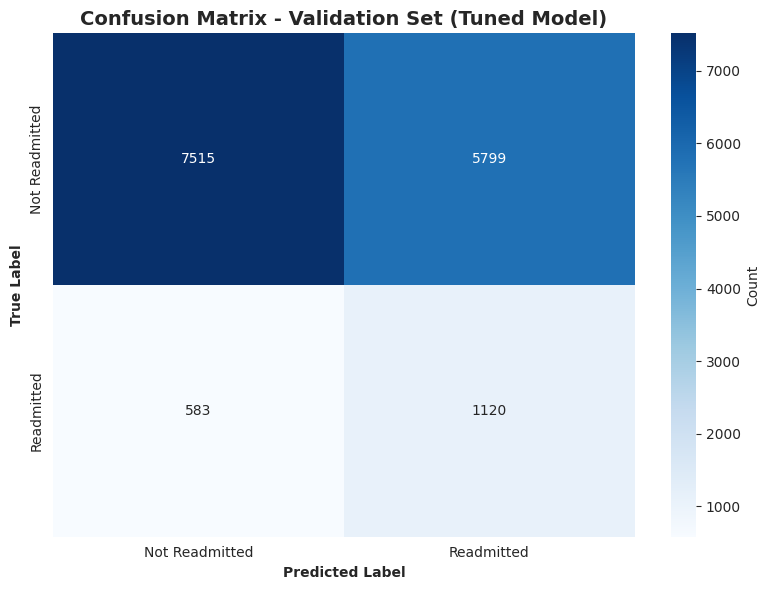


✅ HYPERPARAMETER OPTIMIZATION COMPLETE!

📁 Files saved:
   • optuna_history.html - Optimization progress over time
   • optuna_importance.html - Most important parameters
   • optuna_parallel.html - Parameter interactions
   • optuna_contour.html - Learning rate vs depth analysis
   • confusion_matrix_validation_tuned.png - Performance visualization

🏆 Results Summary:
   Best Recall: 0.6330
   Total trials: 40
   Total time: 44.1 minutes

🎯 Next Step:
   The model 'model_cat_tuned' is ready for threshold optimization!
   You can now run the threshold optimization code.



In [21]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred_tuned_cat)

print("\nConfusion Matrix:")
print("-" * 60)
print(f"  True Negatives:  {cm[0, 0]:5d}  |  False Positives: {cm[0, 1]:5d}")
print(f"  False Negatives: {cm[1, 0]:5d}  |  True Positives:  {cm[1, 1]:5d}")
print("-" * 60)

# Visualize confusion matrix
try:
    import matplotlib.pyplot as plt
    import seaborn as sb

    plt.figure(figsize=(8, 6))
    sb.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Readmitted', 'Readmitted'],
        yticklabels=['Not Readmitted', 'Readmitted'],
        cbar_kws={'label': 'Count'}
    )
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.title('Confusion Matrix - Validation Set (Tuned Model)', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig('confusion_matrix_validation_tuned.png', dpi=300, bbox_inches='tight')
    print("\n✅ Confusion matrix saved: confusion_matrix_validation_tuned.png")
    plt.show()
except:
    pass

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("✅ HYPERPARAMETER OPTIMIZATION COMPLETE!")
print("=" * 80)

print("\n📁 Files saved:")
print("   • optuna_history.html - Optimization progress over time")
print("   • optuna_importance.html - Most important parameters")
print("   • optuna_parallel.html - Parameter interactions")
print("   • optuna_contour.html - Learning rate vs depth analysis")
print("   • confusion_matrix_validation_tuned.png - Performance visualization")

print(f"\n🏆 Results Summary:")
print(f"   Best Recall: {study.best_value:.4f}")
print(f"   Total trials: {len(study.trials)}")
print(f"   Total time: {(time.time() - start_time_phase1)/60:.1f} minutes")

print(f"\n🎯 Next Step:")
print(f"   The model 'model_cat_tuned' is ready for threshold optimization!")
print(f"   You can now run the threshold optimization code.")

print("\n" + "=" * 80)

## 22. Final Model Evaluation on Test Set

Evaluate the final tuned model on the held-out test set for unbiased performance assessment.


STEP 1: FINDING OPTIMAL THRESHOLD (on Validation Set)

📊 Generating prediction probabilities on validation set...
   ✅ Generated probabilities for 15017 validation samples
   Probability range: [0.4319, 0.6140]

📈 Calculating Precision-Recall curve...
   ✅ Calculated 15012 threshold points

🎯 Finding optimal threshold...
   Constraint: Precision must be >= 0.17
   Found 5920 thresholds meeting precision constraint

✅ OPTIMAL THRESHOLD FOUND!
   Threshold:  0.5085
   Recall:     0.5954 ⬆️ (maximized)
   Precision:  0.1700 (>= 0.17)

📊 Generating Precision-Recall curve visualization...
   ✅ Saved: precision_recall_curve_catboost.png


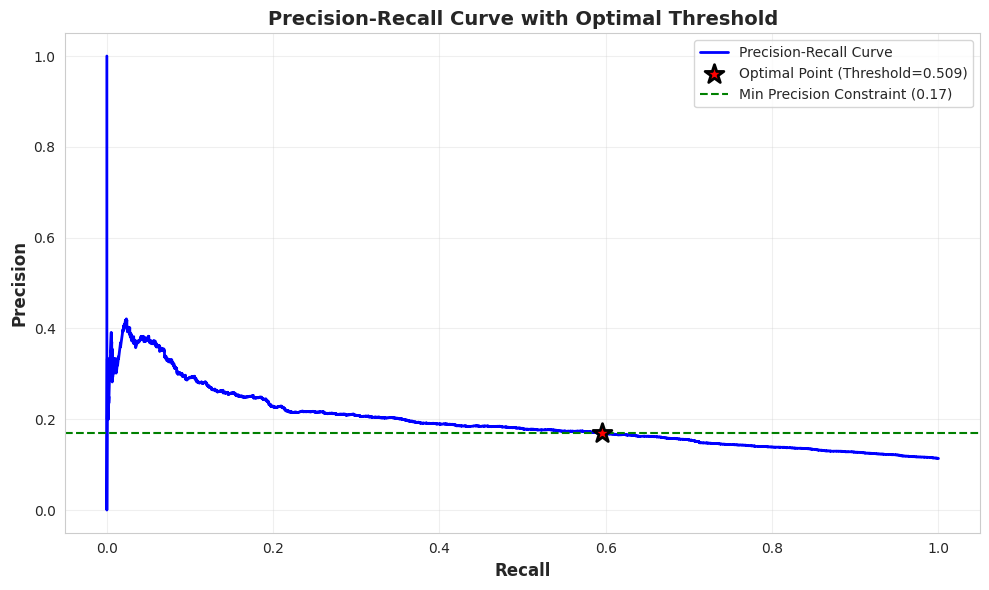


STEP 2: FINAL EVALUATION - TESTING ON HELD-OUT TEST SET
Using Custom Threshold: 0.5085

🔄 Applying model to test set...
   Test set size: 15018 samples
   Positive class ratio: 11.35%
   Predicted positive cases: 6059 (40.34%)

🏁 FINAL TEST SET RESULTS (CatBoost with Optimized Threshold) 🏁

Classification Report:
------------------------------------------------------------
                    precision    recall  f1-score   support

Not Readmitted (0)       0.93      0.63      0.75     13314
    Readmitted (1)       0.18      0.64      0.28      1704

          accuracy                           0.63     15018
         macro avg       0.55      0.63      0.51     15018
      weighted avg       0.85      0.63      0.70     15018


📊 FINAL PERFORMANCE SUMMARY

Test Set Metrics (with threshold = 0.5085):
------------------------------------------------------------
   RECALL:     0.6367 ⬆️
   PRECISION:  0.1791
   F1-SCORE:   0.2795
--------------------------------------------------------

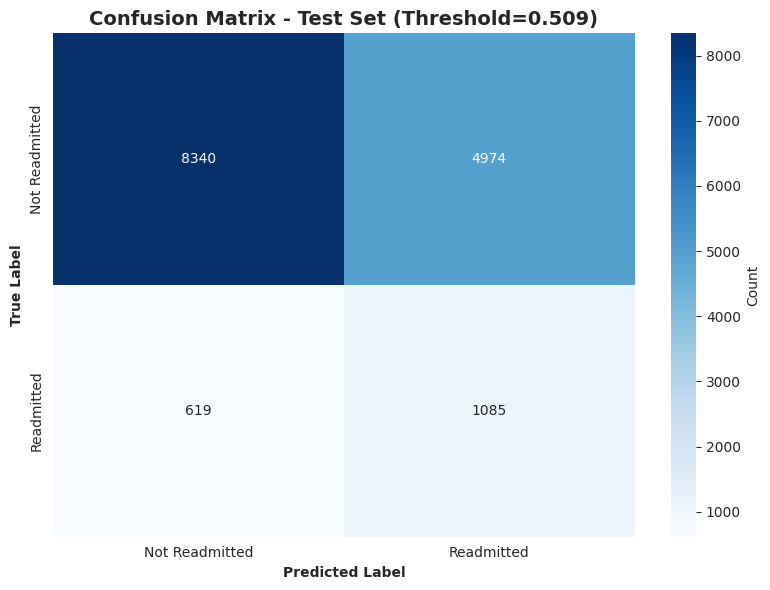


✅ EVALUATION COMPLETE!

Results saved:
   • precision_recall_curve_catboost.png
   • confusion_matrix_test_catboost.png


In [22]:
# ============================================================================
# THRESHOLD OPTIMIZATION & FINAL TEST EVALUATION
# ============================================================================


print("\n" + "=" * 80)
print("STEP 1: FINDING OPTIMAL THRESHOLD (on Validation Set)")
print("=" * 80)

# ============================================================================
# PART A: Get Prediction Probabilities
# ============================================================================

print("\n📊 Generating prediction probabilities on validation set...")

try:
    # Get class probabilities from the tuned CatBoost model
    # [:, 1] extracts probability of positive class (readmission)
    y_proba_val = model_cat_tuned.predict_proba(X_val)[:, 1]
    y_val_true = y_val

    print(f"   ✅ Generated probabilities for {len(y_proba_val)} validation samples")
    print(f"   Probability range: [{y_proba_val.min():.4f}, {y_proba_val.max():.4f}]")

except NameError as e:
    print(f"❌ ERROR: Missing required variable: {e}")
    print("   Make sure you have run the Optuna optimization code first!")
    print("   Required variables: 'model_cat_tuned', 'X_val', 'y_val'")
    raise e

# ============================================================================
# PART B: Calculate Precision-Recall Curve
# ============================================================================

print("\n📈 Calculating Precision-Recall curve...")

# Calculate precision, recall, and thresholds for all possible cutoff points
precision_pr, recall_pr, thresholds_pr = precision_recall_curve(y_val_true, y_proba_val)

print(f"   ✅ Calculated {len(thresholds_pr)} threshold points")

# ============================================================================
# PART C: Find Optimal Threshold with Minimum Precision Constraint
# ============================================================================

print("\n🎯 Finding optimal threshold...")

# CONSTRAINT: Set minimum acceptable precision
# This ensures we don't get too many false positives
MINIMUM_PRECISION = 0.17

print(f"   Constraint: Precision must be >= {MINIMUM_PRECISION:.2f}")

# Align arrays (precision_recall_curve returns one extra value)
# Remove last element from precision/recall to match threshold array length
precision_pr_subset = precision_pr[:-1]
recall_pr_subset = recall_pr[:-1]
thresholds_pr_subset = thresholds_pr

# Find all thresholds where precision meets our minimum requirement
valid_indices = np.where(precision_pr_subset >= MINIMUM_PRECISION)[0]

print(f"   Found {len(valid_indices)} thresholds meeting precision constraint")

if len(valid_indices) > 0:
    # Among valid thresholds, find the one with HIGHEST RECALL
    # This is our objective: maximize recall while maintaining minimum precision
    best_recall_index_within_valid = np.argmax(recall_pr_subset[valid_indices])
    final_best_idx = valid_indices[best_recall_index_within_valid]

    # Save the optimal threshold
    best_threshold_cat = thresholds_pr_subset[final_best_idx]

    print(f"\n✅ OPTIMAL THRESHOLD FOUND!")
    print("=" * 60)
    print(f"   Threshold:  {best_threshold_cat:.4f}")
    print(f"   Recall:     {recall_pr_subset[final_best_idx]:.4f} ⬆️ (maximized)")
    print(f"   Precision:  {precision_pr_subset[final_best_idx]:.4f} (>= {MINIMUM_PRECISION})")
    print("=" * 60)

else:
    # Fallback if no threshold meets the precision constraint
    print(f"\n⚠️ WARNING: No threshold found with Precision >= {MINIMUM_PRECISION}")
    print(f"   Using default threshold: 0.5")
    best_threshold_cat = 0.5

# ============================================================================
# VISUALIZATION: Precision-Recall Curve with Optimal Point
# ============================================================================

print("\n📊 Generating Precision-Recall curve visualization...")

plt.figure(figsize=(10, 6))

# Plot the full PR curve
plt.plot(recall_pr, precision_pr, 'b-', linewidth=2, label='Precision-Recall Curve')

# Mark the optimal point
if len(valid_indices) > 0:
    plt.scatter(
        recall_pr_subset[final_best_idx],
        precision_pr_subset[final_best_idx],
        color='red',
        s=200,
        marker='*',
        edgecolors='black',
        linewidth=2,
        label=f'Optimal Point (Threshold={best_threshold_cat:.3f})',
        zorder=5
    )

# Add minimum precision line
plt.axhline(y=MINIMUM_PRECISION, color='green', linestyle='--',
            label=f'Min Precision Constraint ({MINIMUM_PRECISION})')

# Formatting
plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curve with Optimal Threshold', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve_catboost.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: precision_recall_curve_catboost.png")
plt.show()

# ============================================================================
# STEP 2: FINAL EVALUATION ON TEST SET
# ============================================================================

print("\n" + "=" * 80)
print("STEP 2: FINAL EVALUATION - TESTING ON HELD-OUT TEST SET")
print(f"Using Custom Threshold: {best_threshold_cat:.4f}")
print("=" * 80)

try:
    # ========================================================================
    # Get test set data
    # ========================================================================

    print("\n🔄 Applying model to test set...")
    X_test_final = X_test
    y_test_final = y_test

    print(f"   Test set size: {len(X_test_final)} samples")
    print(f"   Positive class ratio: {y_test_final.mean():.2%}")

    # ========================================================================
    # Generate predictions with optimal threshold
    # ========================================================================

    # Get probabilities
    final_probabilities_cat = model_cat_tuned.predict_proba(X_test_final)[:, 1]

    # Apply the optimal threshold found on validation set
    final_predictions_cat = (final_probabilities_cat >= best_threshold_cat).astype(int)

    print(f"   Predicted positive cases: {final_predictions_cat.sum()} ({final_predictions_cat.mean():.2%})")

    # ========================================================================
    # Calculate metrics
    # ========================================================================

    print("\n" + "=" * 80)
    print("🏁 FINAL TEST SET RESULTS (CatBoost with Optimized Threshold) 🏁")
    print("=" * 80)

    # Detailed classification report
    print("\nClassification Report:")
    print("-" * 60)
    print(classification_report(
        y_test_final,
        final_predictions_cat,
        target_names=['Not Readmitted (0)', 'Readmitted (1)']
    ))

    # Calculate individual metrics
    final_recall_cat = recall_score(y_test_final, final_predictions_cat)
    final_precision_cat = precision_score(y_test_final, final_predictions_cat)
    final_f1_cat = f1_score(y_test_final, final_predictions_cat)

    # ========================================================================
    # Summary comparison
    # ========================================================================

    print("\n" + "=" * 80)
    print("📊 FINAL PERFORMANCE SUMMARY")
    print("=" * 80)

    print(f"\nTest Set Metrics (with threshold = {best_threshold_cat:.4f}):")
    print("-" * 60)
    print(f"   RECALL:     {final_recall_cat:.4f} ⬆️")
    print(f"   PRECISION:  {final_precision_cat:.4f}")
    print(f"   F1-SCORE:   {final_f1_cat:.4f}")
    print("-" * 60)

    # Confusion Matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test_final, final_predictions_cat)

    print("\nConfusion Matrix:")
    print("-" * 60)
    print(f"   True Negatives:  {cm[0, 0]:5d}  |  False Positives: {cm[0, 1]:5d}")
    print(f"   False Negatives: {cm[1, 0]:5d}  |  True Positives:  {cm[1, 1]:5d}")
    print("-" * 60)

    # ========================================================================
    # Confusion Matrix Visualization
    # ========================================================================

    print("\n📊 Generating confusion matrix visualization...")

    plt.figure(figsize=(8, 6))
    sb.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Readmitted', 'Readmitted'],
        yticklabels=['Not Readmitted', 'Readmitted'],
        cbar_kws={'label': 'Count'}
    )
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.title(f'Confusion Matrix - Test Set (Threshold={best_threshold_cat:.3f})',
              fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig('confusion_matrix_test_catboost.png', dpi=300, bbox_inches='tight')
    print("   ✅ Saved: confusion_matrix_test_catboost.png")
    plt.show()

    # ========================================================================
    # Store results for potential further analysis
    # ========================================================================

    print("\n" + "=" * 80)
    print("✅ EVALUATION COMPLETE!")
    print("=" * 80)
    print("\nResults saved:")
    print("   • precision_recall_curve_catboost.png")
    print("   • confusion_matrix_test_catboost.png")

except Exception as e:
    print(f"\n❌ ERROR during final test evaluation: {e}")
    import traceback
    print("\nFull error traceback:")
    print(traceback.format_exc())

## 23. Model Interpretability with SHAP

Use SHAP (SHapley Additive exPlanations) to interpret model predictions and feature contributions.

Loading SHAP...



Running SHAP analysis for the Final Tuned CatBoost Model
Model: CatBoostClassifier
Data Shape: (15017, 49)

Creating TreeExplainer...
Calculating SHAP values for X_val... (This may take time)

Creating SHAP beeswarm plot...

--- ✅ Success! ---
SHAP beeswarm plot saved as: catboost_final_shap_plot.png


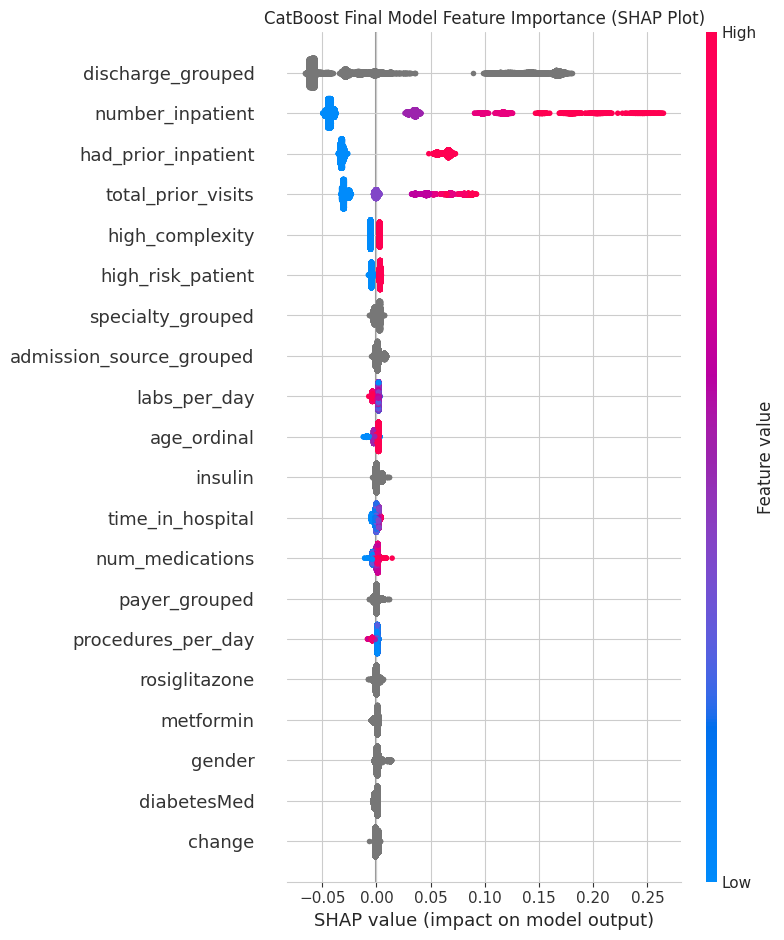

In [23]:


print("Loading SHAP...")
# 1. Initialize SHAP
shap.initjs()

print("\n" + "=" * 80)
print("Running SHAP analysis for the Final Tuned CatBoost Model")
print("=" * 80)

# --- 1. Define the correct model and data ---
# We use the final tuned model 'model_cat_tuned'
# We use the CLEAN validation set 'X_val' (with text)
try:
    model_to_explain = model_cat_tuned
    data_to_explain = X_val

    print(f"Model: {type(model_to_explain).__name__}")
    print(f"Data Shape: {data_to_explain.shape}")

except NameError as e:
    print(f"❌ ERROR: The model ('model_cat_tuned') or data ('X_val') is not defined.")
    raise e

# 2. Create the Explainer
print("\nCreating TreeExplainer...")
explainer_cat = shap.TreeExplainer(model_to_explain)

# 3. Calculate SHAP values
print("Calculating SHAP values for X_val... (This may take time)")
shap_values_cat = explainer_cat.shap_values(data_to_explain)

# 4. Create the beeswarm plot
print("\nCreating SHAP beeswarm plot...")
plt.title("CatBoost Final Model Feature Importance (SHAP Plot)")

# --- 💡 Correction ---
# We pass the entire 'shap_values_cat' matrix (or the correct index if it's a list).
# For CatBoost binary classification, shap_values is often a list [class_0, class_1].
# We plot class_1 for 'Readmitted'.
try:
    if isinstance(shap_values_cat, list):
        # This is the expected case for binary classification
        shap.summary_plot(shap_values_cat[1], data_to_explain, plot_type="dot", show=False)
    else:
        # This handles the case where it might just return the matrix for class 1
        shap.summary_plot(shap_values_cat, data_to_explain, plot_type="dot", show=False)

    # 5. Save the file (before showing)
    save_path = "catboost_final_shap_plot.png"
    plt.savefig(save_path, bbox_inches='tight')

    print(f"\n--- ✅ Success! ---")
    print(f"SHAP beeswarm plot saved as: {save_path}")

    # 6. Show the plot
    plt.show()

except IndexError:
    print("\n❌ ERROR: Tried to access shap_values_cat[1] but it failed.")
    print("   Attempting to plot the raw shap_values object instead...")
    shap.summary_plot(shap_values_cat, data_to_explain, plot_type="dot", show=True)
except Exception as e:
    print(f"\n❌ An error occurred during plotting: {e}")